# Description
______

This script analyzes HYPE future climate and historical simulations as follows:
- The official Ouranos ESPO-G6-R2 v1.0.0 ensemble which includes 15 models with SSP2-4.5 and SSP3-7.0 for a total of 30 ensemble members is used.
- For each of the 30 members, the mean annual flow volume was calculated (sum of flow for each year then calculate the mean across each year) from 2015 to 2100.
- The models that are closest to the median, 75th percentile and 25th percentile of the mean annual flow volume at SMRIB and MREIB were selected from the 30 members (SSP2-4.5 and SSP3-7.0).
- The average annual hydrographs at both gauges are plotted

### Import Libraries

In [1]:
import xarray as xr
import os
import pandas as pd
import matplotlib.pyplot as plt
from dateutil.parser import ParserError
import cycler
import matplotlib.ticker as ticker
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import seaborn as sns
import matplotlib.gridspec as gridspec

### Inputs

In [2]:
# Results directory
results_directory = '../../results/v10_1_results/'

# Start and end years for the future climate period
start_year= 2015
end_year= 2100

# Start and end years for historical climate period
hist_start= 1981
hist_end= 2015

# HYPE output variable
variable= 'cout' 

# Path to HYPE output files
mreib_historical_path= '../../../SMM_Models/hype/model/v10_model/final_model/hds_v3/results/0058308.txt'
smrib_historical_path= '../../../SMM_Models/hype/model/v10_model/final_model/hds_v3/results/0058208.txt'

# Output directory for plots
output_directory= './outputs/'

### Define Functions

In [3]:
def extract_ensemble(results_directory: str, subbasin_id: str, variable, exclude_members=True):
    """
    Extracts ensemble data from files, filters by subbasin ID, and optionally excludes members not found in the offical ensemble.

    Parameters:
        results_directory (str): Path to the directory containing result files.
        subbasin_id (str): Identifier for filtering files belonging to a specific subbasin.
        exclude_members (bool): If True, excludes specified model members.

    Returns:
        xarray.DataArray: Combined ensemble data as an xarray DataArray.
    """
    # List of model names to exclude (not in official ensemble)
    exclude_models = [
        'CanESM5', 'CNRM-CM6-1', 'EC-Earth3', 'IPSL-CM6A-LR',
        'UKESM1-0-LL', 'NorESM2-MM', 'EC-Earth3-CC', 'NESM3',
        'EC-Earth3-Veg', 'INM-CM4-8', 'TaiESM1'
    ]
    
    # Check for files of required subbasin_id
    file_list = [os.path.join(results_directory, filename) for filename in os.listdir(results_directory)
                 if subbasin_id in filename]  # Only filter by subbasin_id
    
    # Create an empty list to store xarray DataArrays
    data_arrays: List[xr.DataArray] = []
    member_names = []  # To store the 'name' of each DataArray for concatenation

    # Loop through each file
    for file_path in file_list:
        # Extract the filename without extension to use as the member name
        member_name = os.path.splitext(os.path.basename(file_path))[0]

        # Conditionally exclude models if exclude_members is True
        if exclude_members and (any(excluded in member_name for excluded in exclude_models) or 'ssp585' in member_name):
            continue
        
        # Read the file into a pandas DataFrame
        df = pd.read_csv(file_path, sep='\t', index_col=0, low_memory=False)

        # Drop the first row to remove units
        df = df.iloc[1:]
        
        df= df[[variable]]

        # Convert the DataFrame to an xarray DataArray
        data_array = xr.DataArray(df.values, dims=('DATE', 'variable'),
                                  coords={'DATE': df.index, 'variable': df.columns})
        
        # Assign the filename as the name of the DataArray
        data_array.name = member_name
        
        # Append the DataArray to the list
        data_arrays.append(data_array)
        member_names.append(member_name)  # Keep track of the member name

    # Check if any valid data arrays exist
    if not data_arrays:
        return xr.DataArray()  # Return an empty DataArray if no valid members are left
    
    # Concatenate the list of DataArrays along dimension 'member'
    ds = xr.concat(data_arrays, dim='member')
    
    # Add the member names as a coordinate
    ds.coords['member'] = ('member', member_names)

    # Convert 'DATE' coordinate to datetime, specifying the format and handling errors
    ds['DATE'] = pd.to_datetime(ds['DATE'], format='%Y-%m-%d', errors='coerce')

    # Select the specified variable from the dataset
    var_data = ds.sel(variable=variable)
    
    return var_data

In [4]:
def find_mean_annual_vol(full_ensemble, start_year, end_year, gauge_name, output_directory):
    """
    Calculates the mean annual volume for the ensemble and returns results for the full official ensemble, ssp245 and ssp370 seperately. 
    
    Parameters:
        full_ensemble (xarray.DataArray): Data containing streamflow in the official ensemble
        start_year (int): Start year for filtering data 
        end_year (int): End year for filtering data 
        gauge_name (str): Name of the stream gauge for the plot title.
        output_directory (str): Directory to save the plot.
    """
    # Create an empty dictionary to store annual sums for each member
    annual_sums = {}

    # Seconds in a day for conversion
    seconds_per_day = 24 * 60 * 60  # 86,400 seconds in a day

    # Loop through each member in the dataset
    for member_name in full_ensemble.member.values:
        # Select the member data
        member_data = full_ensemble.sel(member=member_name)
        
        # Ensure numeric conversion if data is stored as strings
        if member_data.dtype == object:
            member_data = member_data.astype(float)
        
        # Convert the DataArray to a DataFrame with DATE as the index
        member_df = member_data.to_dataframe(name='cout').reset_index()
        
        # Extract the year and month from the DATE column
        member_df['Year'] = member_df['DATE'].dt.year
        member_df['Month'] = member_df['DATE'].dt.month
        
        # # Filter the DataFrame to include only rows between April 1st and September 30th
        # filtered_df = member_df[
        #     (member_df['DATE'].dt.month >= 4) & (member_df['DATE'].dt.month <= 10)
        # ].copy()
        
        # Convert daily flow rate (m³/s) to total daily volume (m³) by multiplying by the number of seconds in a day
        member_df['Daily_Volume_m3'] = member_df['cout'] * seconds_per_day
        
        # Group by year and calculate the annual sum of daily volumes
        annual_sum = member_df.groupby('Year')['Daily_Volume_m3'].sum()
        
        # Add the annual sum to the dictionary
        annual_sums[member_name] = annual_sum

    # Combine all annual sums into a single DataFrame
    annual_sums_df = pd.DataFrame(annual_sums)

    # Filter the DataFrame to include only rows where Year is between start_year and end_year
    filtered_annual_sums_df = annual_sums_df[(annual_sums_df.index >= start_year) & (annual_sums_df.index <= end_year)]

    # Sort DataFrame columns by member for consistency
    filtered_annual_sums_df = filtered_annual_sums_df.sort_index(axis=1)

    # Calculate the mean across all years for each member and sort in descending order
    total_mean_df = filtered_annual_sums_df.mean().sort_values(ascending=False).to_frame(name='Mean')
    total_mean_df.index.name = 'Member'

    # Split the DataFrame into two based on column names containing "ssp245" and "ssp370"
    ssp245_df = filtered_annual_sums_df.filter(like='ssp245')
    ssp370_df = filtered_annual_sums_df.filter(like='ssp370')

    # Calculate the mean of the columns for each DataFrame
    ssp245_mean = ssp245_df.mean()
    ssp370_mean= ssp370_df.mean()

    # Convert column means to DataFrames, sort them in descending order, and set the index name to "Member"
    ssp245_mean = ssp245_mean.sort_values(ascending=False).to_frame(name='Mean')
    ssp245_mean.index.name = 'Member'

    ssp370_mean = ssp370_mean.sort_values(ascending=False).to_frame(name='Mean')
    ssp370_mean.index.name = 'Member'

    return total_mean_df, ssp245_mean, ssp370_mean

In [5]:
def ensemble_boxplot(output_directory, start_year, end_year, **dataframes):
    """
    Create a box plot with each DataFrame as a group on the x-axis, along with separate subplots for merib and smrib.

    Parameters:
        output_directory (str): Directory to save the plot.
        start_year (int): Start year for the plot title.
        end_year (int): End year for the plot title.
        **dataframes: DataFrames with columns 'Sum'. Keys will be used as x-axis labels.
    """
    # Extract data and labels
    data = [df['Mean'].values for df in dataframes.values()]
    labels = list(dataframes.keys())

    # Separate merib and smrib data
    mreib_data = [df['Mean'].values for name, df in dataframes.items() if 'mreib' in name.lower()]
    smrib_data = [df['Mean'].values for name, df in dataframes.items() if 'smrib' in name.lower()]

    # Extract relevant part of the name after the underscore
    mreib_labels = [name.split('_')[-1] for name in dataframes.keys() if 'mreib' in name.lower()]
    smrib_labels = [name.split('_')[-1] for name in dataframes.keys() if 'smrib' in name.lower()]

    # Create the figure and grid layout
    fig = plt.figure(figsize=(14, 8))
    spec = gridspec.GridSpec(nrows=2, ncols=2, width_ratios=[3, 1], height_ratios=[1, 1], figure=fig)

    # Main box plot (spans two rows in the left column)
    main_ax = fig.add_subplot(spec[:, 0])
    main_ax.boxplot(data, tick_labels=labels, patch_artist=True, boxprops=dict(facecolor="lightblue", color="black"),
                   medianprops=dict(color="black", linewidth=1))  # Set median line to black
    main_ax.set_xlabel("Location and Scenario/Ensemble")
    main_ax.set_ylabel("Average Annual Streamflow Volume (m³/year)")
    main_ax.set_title(f'Average Annual Streamflow Volume from {start_year} to {end_year}')
    main_ax.grid(axis="y", linestyle="--", alpha=0.7)

    # Subplot for smrib (top right)
    smrib_ax = fig.add_subplot(spec[0, 1])
    if smrib_data:
        smrib_ax.boxplot(smrib_data, tick_labels=smrib_labels, patch_artist=True, boxprops=dict(facecolor="lightcoral", color="black"),
                         medianprops=dict(color="black", linewidth=1))  # Set median line to black
        smrib_ax.set_title("SMRIB")
        smrib_ax.grid(axis="y", linestyle="--", alpha=0.7)
      #  smrib_ax.set_xlabel("Scenario")

    # Subplot for mreib (bottom right)
    mreib_ax = fig.add_subplot(spec[1, 1])
    if mreib_data:
        mreib_ax.boxplot(mreib_data, tick_labels=mreib_labels, patch_artist=True, boxprops=dict(facecolor="lightgreen", color="black"),
                         medianprops=dict(color="black", linewidth=1))  # Set median line to black
        mreib_ax.set_title("MREIB")
        mreib_ax.grid(axis="y", linestyle="--", alpha=0.7)
        mreib_ax.set_xlabel("Scenario/Ensemble")
        
    # Adjust layout
    plt.tight_layout()

    # Save the plot to the output directory
    output_path = os.path.join(output_directory, 'total_volume_boxplot.png')
    plt.savefig(output_path, bbox_inches="tight")
    plt.show()

In [6]:
def get_min_max_med(stm, milk, output_directory):
    """
    Given two DataFrames (`stm` and `milk`), calculates:
    1. The best matching index for `stm` based on percentiles.
    2. The best matching index for `milk` based on percentiles.
    3. The best matching index that minimizes the combined distance from both.

    Parameters:
        stm (pd.DataFrame): DataFrame with SMRIB data.
        milk (pd.DataFrame): DataFrame with MREIB data.
        output_directory (str): Path to save the output CSV.

    Returns:
        pd.DataFrame: A DataFrame where the percentiles are columns, and the best matching 
                      indices for `StM`, `Milk`, and `Combined` are rows.
    """

    # Function to find the closest index for a given percentile value
    def closest_index(df, value):
        return (df['Mean'] - value).abs().idxmin()

    # Function to calculate the closest member based on combined distance
    def calculate_closest(value_stm, value_milk, stm, milk):
        stm_copy = stm[['Mean']].copy()
        milk_copy = milk[['Mean']].copy()

        # Calculate normalized distances
        stm_copy['normalized_distance'] = (stm_copy['Mean'] - value_stm).abs() / abs(value_stm)
        milk_copy['normalized_distance'] = (milk_copy['Mean'] - value_milk).abs() / abs(value_milk)

        # Modify the indexes to match format
        stm_copy.index = stm_copy.index.str.replace(r'^([^_]+)_[^_]+_(.*)$', r'\1_\2', regex=True)
        milk_copy.index = milk_copy.index.str.replace(r'^([^_]+)_[^_]+_(.*)$', r'\1_\2', regex=True)

        # Merge DataFrames
        merged = pd.merge(
            stm_copy[['normalized_distance']],
            milk_copy[['normalized_distance']],
            left_index=True,
            right_index=True,
            suffixes=('_stm', '_milk')
        )

        # Calculate total distance
        merged['distance_sum'] = merged['normalized_distance_stm'] + merged['normalized_distance_milk']

        # Find the closest index
        return merged['distance_sum'].idxmin()

    # Calculate percentiles for both DataFrames
    metrics = {
        '75th_percentile': (stm['Mean'].quantile(0.75), milk['Mean'].quantile(0.75)),
        'median': (stm['Mean'].median(), milk['Mean'].median()),
        '25th_percentile': (stm['Mean'].quantile(0.25), milk['Mean'].quantile(0.25))
    }

    # Find best matching index for `stm` separately (stm should use value_stm)
    best_stm = {
        metric: closest_index(stm, value_stm)
        for metric, (value_stm, _) in metrics.items()
    }

    # Find best matching index for `milk` separately (milk should use value_milk)
    best_milk = {
        metric: closest_index(milk, value_milk)
        for metric, (_, value_milk) in metrics.items()
    }

    # Find best matching index for combined distance
    best_combined = {
        metric: calculate_closest(value_stm, value_milk, stm, milk)
        for metric, (value_stm, value_milk) in metrics.items()
    }

    # Create a single DataFrame
    result_df = pd.DataFrame({
        '75th_percentile': [best_stm['75th_percentile'], best_milk['75th_percentile'], best_combined['75th_percentile']],
        'median': [best_stm['median'], best_milk['median'], best_combined['median']],
        '25th_percentile': [best_stm['25th_percentile'], best_milk['25th_percentile'], best_combined['25th_percentile']]
    }, index=['StM', 'Milk', 'Combined'])

    result_df.index.name = 'Location'

    # Save to CSV
    output_path = os.path.join(output_directory, 'best_fitting_members.csv')
    result_df.to_csv(output_path)

    return result_df

In [7]:
def process_average_annual_ensemble(results_directory: str, 
                     subbasin_id: str, 
                     scenario: str, 
                     start_year: int, 
                     end_year: int, 
                     variable: str) -> xr.DataArray:
    """
    Processes ensemble data for a specified subbasin, scenario, and variable, 
    filtering by start and end year, and calculates average annual runoff.

    Parameters:
        results_directory (str): Directory containing the ensemble files.
        subbasin_id (str): Subbasin ID to filter the files.
        scenario (str): Scenario identifier to filter the files.
        start_year (int): Start year for filtering data.
        end_year (int): End year for filtering data.
        variable (str): Variable name to select from the dataset.

    Returns:
        xr.DataArray: Processed average annual runoff shifted to start on October 1st.
    """
    # List of member names to exclude
    exclude_members = [
        "CanESM5", "CNRM-CM6-1", "EC-Earth3", "IPSL-CM6A-LR", "UKESM1-0-LL",
        "NorESM2-MM", "EC-Earth3-CC", "NESM3", "EC-Earth3-Veg", "INM-CM4-8", "TaiESM1"
    ]
    
    # Check for files of required subbasin and scenario
    file_list = [os.path.join(results_directory, filename) 
                 for filename in os.listdir(results_directory) 
                 if (subbasin_id in filename) and (scenario in filename)]
    
    # Create an empty list to store xarray DataArrays
    data_arrays: List[xr.DataArray] = []

    # Loop through each file
    for file_path in file_list:
        # Skip files with excluded member names
        if any(member in file_path for member in exclude_members):
            continue
        
        # Read the file into a pandas DataFrame
        df = pd.read_csv(file_path, sep='\t', index_col=0, low_memory=False)

        # Drop the first row
        df = df.iloc[1:]

        # Convert the DataFrame to an xarray DataArray
        data_array = xr.DataArray(df.values, dims=('DATE', 'variable'), coords={'DATE': df.index, 'variable': df.columns})

        # Append the DataArray to the list
        data_arrays.append(data_array)

    # Concatenate the list of DataArrays along a new dimension 'member'
    ds = xr.concat(data_arrays, dim='member')

    # Convert 'DATE' coordinate to datetime, specifying the format and handling errors
    ds['DATE'] = pd.to_datetime(ds['DATE'], format='%Y-%m-%d', errors='coerce')

    # Convert 'member' coordinate to float
    ds = ds.astype(float)

    # Select the specified variable from the dataset
    var_data = ds.sel(variable=variable)

    # Sort the dataset along the 'DATE' coordinate
    var_data = var_data.sortby('DATE')

    # Filter the sorted dataset to include only data between the specified years
    var_data = var_data.sel(DATE=(var_data['DATE'].dt.year >= start_year) & (var_data['DATE'].dt.year <= end_year))

    # Calculate the mean of these daily means for each member to get the average annual runoff
    average_annual_runoff = var_data.groupby('DATE.dayofyear').mean(dim='DATE')

    # Drop leap day (dayofyear = 366)
    average_annual_runoff = average_annual_runoff.sel(dayofyear=~(average_annual_runoff['dayofyear'] == 366))
    
    # Shift data to start on October 1st
    dayofyear_shifted = ((average_annual_runoff['dayofyear'] - 274) % 365) + 1

    # Update the 'dayofyear' coordinate with the shifted values
    average_annual_runoff['dayofyear'] = dayofyear_shifted

    # Sort the data_array along the 'dayofyear' coordinate
    average_annual_runoff_shifted = average_annual_runoff.sortby('dayofyear')
    
    return average_annual_runoff_shifted

In [8]:
def process_historical(filepath: str, variable: str, start_date: str = '1981-01-01', end_date: str = '2015-12-31') -> pd.Series:
    """
    Processes historical data from HYPE output files into an average annual timeseries

    Parameters:
        filepath (str): Path to the HYPE output file.
        variable (str): The variable name in the file to process.
        start_date (str): The start date for the data filter (default is '1981-01-01').
        end_date (str): The end date for the data filter (default is '2015-12-31').

    Returns:
        pd.Series: A pandas Series with the historical average annual timeseries
    """
    
    # Read the tab-separated text file into a DataFrame
    sim: pd.DataFrame = pd.read_csv(filepath, delimiter='\t', index_col=0, low_memory=False)
    
    # Drop the first row
    sim = sim.iloc[1:]
    
    # Drop all columns except for 'variable'
    sim = sim[[variable]]
    
    # Convert index to datetime
    sim.index = pd.to_datetime(sim.index)
    
    # Trim the DataFrame between dates
    sim = sim.loc[start_date:end_date]
    
    # Get the length of the DataFrame before dropping NaN values
    original_length: int = len(sim)
    
    # Convert the 'variable' column to numeric
    sim[variable] = pd.to_numeric(sim[variable], errors='coerce')

    # Replace -9999 values with NaN
    sim[variable] = sim[variable].replace(-9999, pd.NA)
    
    # Drop NaN values if any
   # sim = sim.dropna()
    
    # Get the length of the DataFrame after dropping NaN values
    new_length: int = len(sim)
    
    # Check if any NaN values were replaced
    if new_length < original_length:
        print("NaN values were replaced during conversion.")

    # Resample the data to calculate the mean for each day of the year across all years
    sim_resampled: pd.Series = sim.groupby(sim.index.dayofyear)[variable].mean()

    # Drop leap day (dayofyear = 366) if it exists to be consistent with future climate members
    sim_resampled = sim_resampled[sim_resampled.index != 366]

    # Shift dayofyear to start on October 1st and wrap around
    dayofyear_shifted = ((sim_resampled.index - 274) % 365) + 1

    # Update the index of the Series with the shifted dayofyear values
    sim_resampled.index = dayofyear_shifted

    # Sort the Series by index to ensure the correct order
    sim_shifted = sim_resampled.sort_index()
    
    return sim_shifted

In [9]:
def average_annual_plot(ens1: xr.DataArray, ens2: xr.DataArray, 
                        historical: pd.DataFrame, gauge_name: str, 
                        ens1_label: str, ens2_label: str, 
                        historical_label: str, start_year: int, end_year: int, 
                        var_name: str, output_directory: str):
    """
    Plots the average annual values for two future ensembles and a historical dataset. 
    The plot includes shaded areas representing the range of each ensemble, 
    the mean of the ensembles, and the historical trace.

    Parameters:
        ens1 (xr.DataArray): First future ensemble dataset with 'dayofyear' and 'member' dimensions.
        ens2 (xr.DataArray): Second future ensemble dataset with 'dayofyear' and 'member' dimensions.
        historical (pd.DataFrame): Historical data with 'dayofyear' as index.
        gauge_name (str): Name of the gauge for the plot title.
        ens1_label (str): Label for the first ensemble in the legend.
        ens2_label (str): Label for the second ensemble in the legend.
        historical_label (str): Label for the historical dataset in the legend.
        start_year (int): Start year for the analysis.
        end_year (int): End year for the analysis.
        var_name (str): Variable name for y-axis label.
        output_directory (str): Directory to save the output plot.

    Returns:
        None
    """
    # Set the figure size
    plt.figure(figsize=(16, 8))  # Adjust width and height as needed

    # Plot the historical trace
    historical.plot(label=historical_label, color='red')

    # Fill between lines for ens1
    plt.fill_between(
        ens1['dayofyear'],
        ens1.min(dim='member'),
        ens1.max(dim='member'),
        color='indigo',
        alpha=0.2
    )

    # Fill between lines for ens2
    plt.fill_between(
        ens2['dayofyear'],
        ens2.min(dim='member'),
        ens2.max(dim='member'),
        color='blue',
        alpha=0.2
    )

    # Calculate and plot the mean of each ensemble
    ens1_mean = ens1.mean(dim='member')
    ens2_mean = ens2.mean(dim='member')

    ens1_mean.plot(color='indigo', linestyle='-', label=ens1_label)
    ens2_mean.plot(color='blue', linestyle='-', label=ens2_label)

    # Manually create legend handles and labels
    legend_handles = [
        Patch(facecolor='indigo', alpha=0.2, label=ens1_label),
        Patch(facecolor='blue', alpha=0.2, label=ens2_label),
        Line2D([0], [0], color='indigo', lw=2, linestyle='-', label=f'{ens1_label} Mean'),
        Line2D([0], [0], color='blue', lw=2, linestyle='-', label=f'{ens2_label} Mean'),
        Line2D([0], [0], color='red', lw=2, label=historical_label)
    ]

    # Add legend with custom handles and labels
    plt.legend(handles=legend_handles)

    # Customize labels and title
    plt.xlabel('Day of Year (Starting Oct 1st)')
    plt.ylabel(f'Average Daily {var_name}')
    plt.title(f'{gauge_name} Average Daily {var_name} Between {start_year} and {end_year} for Official Ensemble')

    # Save the plot to the output directory
    file_path_allssp = os.path.join(output_directory, f'{gauge_name}_{start_year}_average_annual.png')
    plt.savefig(file_path_allssp)

    plt.show()


### Find Members

In [10]:
# # Extract the offical ensembles
# milk_official_ensemble= extract_ensemble(results_directory, '58308', variable, True)
# stm_official_ensemble= extract_ensemble(results_directory, '58208', variable, True)

In [11]:
# # Calculate the mean annual volume for each ensemble member in each scenario/location
# milk_official, milk_ssp245, milk_ssp370= find_mean_annual_vol(milk_official_ensemble, start_year, end_year, 'MREIB', output_directory)
# stm_official, stm_ssp245, stm_ssp370= find_mean_annual_vol(stm_official_ensemble, start_year, end_year, 'SMRIB', output_directory)

In [12]:
# # Create the boxplot for each group of members
# ensemble_boxplot(
#     output_directory,
#     start_year,
#     end_year,
#     MREIB_ssp245=milk_ssp245,
#     MREIB_ssp370=milk_ssp370,
#     SMRIB_ssp245=stm_ssp245,
#     SMRIB_ssp370=stm_ssp370,
#     MREIB_Official= milk_official,
#     SMRIB_Official= stm_official
# )

In [13]:
# med = stm_official['Mean'].median()
# stm_official['diff']= np.abs(stm_official['Mean'] - med)

In [14]:
# min_diff_index = stm_official['diff'].idxmin()
# print(f"Index of row with minimum diff value: {min_diff_index}")

In [15]:
# # Compute percentiles
# percentiles_milk = milk_official['Mean'].quantile([0.25, 0.5, 0.75])

# # Find the closest indices
# closest_indices_milk = [
#     (milk_official['Mean'] - p).abs().idxmin()
#     for p in percentiles_milk
# ]

# # Print results
# print("Milk 25th Percentile Index:", closest_indices_milk[0])
# print("Milk 50th Percentile Index (Median):", closest_indices_milk[1])
# print("Milk 75th Percentile Index:", closest_indices_milk[2])

In [16]:
# # Compute percentiles
# percentiles_stm = stm_official['Mean'].quantile([0.25, 0.5, 0.75])

# # Find the closest indices
# closest_indices_stm = [
#     (stm_official['Mean'] - p).abs().idxmin()
#     for p in percentiles_stm
# ]

# # Print results
# print("StM 25th Percentile Index:", closest_indices_stm[0])
# print("StM 50th Percentile Index (Median):", closest_indices_stm[1])
# print("StM 75th Percentile Index:", closest_indices_stm[2])

In [17]:
# # Get members matching 75th, med and 25th percentiles for all groups of members
# #ssp245= get_min_max_med(milk_ssp245, stm_ssp245)
# #ssp370= get_min_max_med(milk_ssp370, stm_ssp370)
# combined_official= get_min_max_med(milk_official, stm_official,output_directory)

In [18]:
# # Visualize the final choice of ensemble members coming from full official ensemble (combining ssp245 and 370)
# combined_official

### Average Annual Plots

In [19]:
# Create averate annual data for MREIB ssp245
mreib_ssp245= process_average_annual_ensemble(results_directory, '58308', 'ssp245', start_year, end_year, variable)

# Create average annual pseudo historical for MREIB ssp245
mreib_hist_ssp245= process_average_annual_ensemble(results_directory, '58308', 'ssp245', hist_start, hist_end, variable)

In [20]:
# Create averate annual data for MREIB ssp370
mreib_ssp370 = process_average_annual_ensemble(results_directory, '58308', 'ssp370', start_year, end_year, variable)

# Create average annual pseudo historical for MREIB ssp370
mreib_hist_ssp370 = process_average_annual_ensemble(results_directory, '58308', 'ssp370', hist_start, hist_end,  variable)

In [21]:
# Create averate annual data for SMRIB ssp245
smrib_ssp245 = process_average_annual_ensemble(results_directory, '58208', 'ssp245', start_year, end_year, variable)

# Create average annual pseudo historical for SMRIB ssp245
smrib_hist_ssp245 = process_average_annual_ensemble(results_directory, '58208', 'ssp245', hist_start, hist_end, variable)

In [22]:
# Create averate annual data for SMRIB ssp370
smrib_ssp370 = process_average_annual_ensemble(results_directory, '58208', 'ssp370', start_year, end_year, variable)

# Create average annual pseudo historical for SMRIB ssp370
smrib_hist_ssp370 = process_average_annual_ensemble(results_directory, '58208', 'ssp370', hist_start, hist_end, variable)

In [23]:
# Extract historical data for SMRIB and MREIB
mreib_historical= process_historical(mreib_historical_path, variable, start_date="1981-01-01", end_date="2015-12-31")
smrib_historical= process_historical(smrib_historical_path, variable, start_date="1981-01-01", end_date="2015-12-31")

# Extract observed data for SMRIB and MREIB
mreib_obs_historical= process_historical(mreib_historical_path, 'rout', start_date="1981-01-01", end_date="2015-12-31")
smrib_obs_historical= process_historical(smrib_historical_path, 'rout', start_date="1981-01-01", end_date="2015-12-31")

In [24]:
# # MREIB average annual plot
# average_annual_plot(mreib_ssp245, mreib_ssp370, mreib_historical, 'MREIB', 'ssp245', 'ssp370', 
#                     'RDRSv2.1 Historical', start_year, end_year, 'Streamflow (cms)', output_directory)

In [25]:
# # SMRIB average annual plot
# average_annual_plot(smrib_ssp245, smrib_ssp370, smrib_historical, 'SMRIB', 'ssp245', 'ssp370', 
#                     'RDRSv2.1 Historical', start_year, end_year, 'Streamflow (cms)', output_directory)

### Pseudo Historical

In [26]:
# # MREIB average annual plot
# average_annual_plot(mreib_hist_ssp245, mreib_hist_ssp370, mreib_historical, 'MREIB', 'ssp245', 'ssp370', 
#                     'RDRSv2.1 Historical', hist_start, hist_end, 'Streamflow (cms)', output_directory)

In [27]:
# # SMRIB pseudo historical average annual plot
# average_annual_plot(smrib_hist_ssp245, smrib_hist_ssp370, smrib_historical, 'SMRIB', 'ssp245', 'ssp370', 
#                     'RDRSv2.1 Historical', hist_start, hist_end, 'Streamflow (cms)', output_directory)

### Combined Plot

In [28]:
def TtCoM(data):
    """Compute the Time to Center of Mass (TtCoM)"""
    days = np.arange(1, 366)  # Days 1 to 365
    total_flow = np.sum(data)
    
    if total_flow > 0:
        return np.sum(days * data) / total_flow
    else:
        return np.nan

def TtP(data):
    """Compute the Time to Peak (TtP)"""
    if isinstance(data, xr.DataArray):  # Check if data is an xarray DataArray
        return int(data.argmax().item()) + 1  # Convert to integer
    else:
        return np.argmax(data) + 1  # Use NumPy's argmax for regular arrays
        
def SpringPulseOnset(data):
    """Compute the onset of the spring pulse"""
    mean_flow = np.mean(data)
    cumulative_sum = np.cumsum(data - mean_flow)
    
    if isinstance(data, xr.DataArray):  
        onset_day = int(cumulative_sum.argmin().item()) + 1  # Ensure we get a raw integer
    else:
        onset_day = np.argmin(cumulative_sum) + 1
    
    return onset_day

In [29]:
def compute_hydrologic_metrics(data, mean_dim=None, historical=None):
    """
    Compute Time to Center of Mass (TtCoM), Time to Peak (TtP), 
    Spring Pulse Onset, and Total Flow Volume for a given DataArray. 
    If historical values are provided, return both the computed values 
    and the difference between the current ensemble and the historical values 
    (future - historical).

    Parameters:
        data (xr.DataArray): Input hydrologic data.
        mean_dim (str, optional): Dimension along which to compute the mean 
                                  before applying metrics.
        historical (list, optional): A list of historical values for comparison 
                                     [TtCoM, TtP, Spring Pulse Onset, Total Volume].

    Returns:
        tuple: 
            - result (list): [TtCoM, TtP, Spring Pulse Onset, Peak Flow, Total Volume] as numeric values.
            - difference (list or None): [Computed - Historical] for each metric if historical is provided, otherwise None.
                                         A negative value indicates the event is occurring earlier.
    """
    if mean_dim:
        data_mean = data.mean(dim=mean_dim)
    else:
        data_mean = data

    # Compute metrics
    ttcom = float(TtCoM(data_mean))  # Time to Center of Mass
    ttp = int(TtP(data_mean))  # Time to Peak
    spring_pulse_onset = int(SpringPulseOnset(data_mean))  # Spring Pulse Onset
    peak_flow = float(data_mean.max())  # Peak Flow as maximum value
    total_volume = float(data_mean.sum()) * 86400  # Total Volume (converted to volume)

    # Result list
    result = [ttcom, ttp, spring_pulse_onset, peak_flow, total_volume]

    if historical is not None:
        # Compute the difference for each metric
        difference = [
            r - h if i != 4 else ((r - h) / h) * 100  # For volume, compute percentage difference
            for i, (r, h) in enumerate(zip(result, historical))
        ]
        return result, difference

    
    return result, None

In [30]:
# Create a dictionary to map variables to corresponding names and units
variable_dict = {
    'cout': {'name': 'Streamflow', 'unit': 'cms'},
    'upsnow': {'name': 'Mean Upstream SWE', 'unit': 'mm'},
    'upsoim': {'name': 'Mean Upstream Soil Moisture', 'unit': 'mm'},
    'upcprc': {'name': 'Mean Upstream Precipitation', 'unit': 'mm/day'},
    'upctmp': {'name': 'Mean Upstream Temperature', 'unit': 'C'}
}

# Assuming `variable` is one of the keys in the dictionary
variable_name = variable_dict[variable]['name']
variable_unit = variable_dict[variable]['unit']

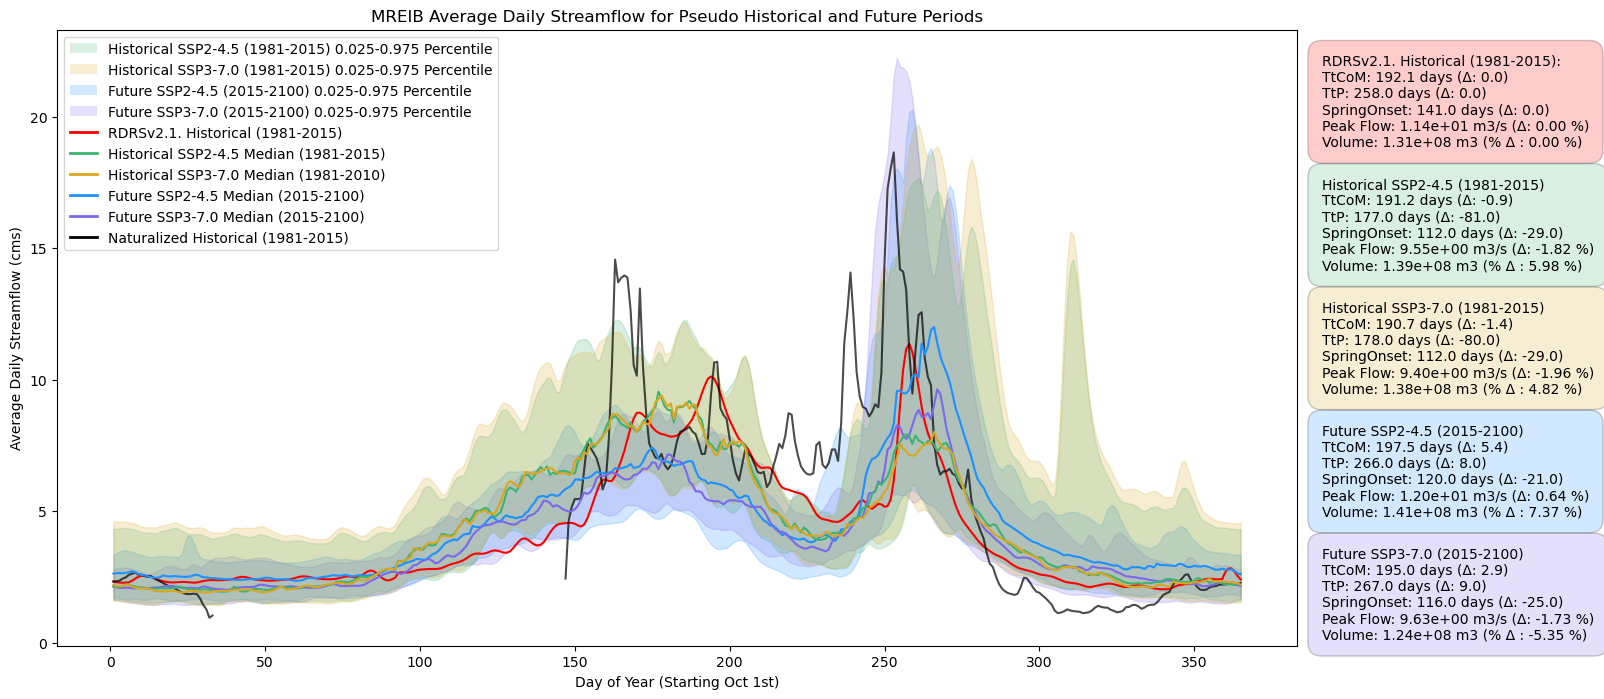

In [31]:
# Set the figure size
plt.figure(figsize=(16, 8))  # Adjust width and height as needed

# Define colors for ensembles
future_color1 = 'dodgerblue'
future_color2 = 'mediumslateblue'
historical_color1 = 'mediumseagreen'
historical_color2 = 'goldenrod'
historical_forcing_color = 'red'
historical_obs_color = 'black'  # New color for observed historical

# Plot the historical trace only if variable is 'cout'
mreib_historical.plot(label='RDRSv2.1. Historical', color=historical_forcing_color)
if variable == 'cout':  # Only plot observed historical if variable is 'cout'
    mreib_obs_historical.plot(label='Observed Historical', color=historical_obs_color, alpha=0.7)

# Fill between lines for each ensemble using 2.5th and 97.5th percentiles
plt.fill_between(
    mreib_ssp245['dayofyear'],
    mreib_ssp245.quantile(0.025, dim='member'),
    mreib_ssp245.quantile(0.975, dim='member'),
    color=future_color1,
    alpha=0.2
)
plt.fill_between(
    mreib_ssp370['dayofyear'],
    mreib_ssp370.quantile(0.025, dim='member'),
    mreib_ssp370.quantile(0.975, dim='member'),
    color=future_color2,
    alpha=0.2
)
plt.fill_between(
    mreib_hist_ssp245['dayofyear'],
    mreib_hist_ssp245.quantile(0.025, dim='member'),
    mreib_hist_ssp245.quantile(0.975, dim='member'),
    color=historical_color1,
    alpha=0.2
)
plt.fill_between(
    mreib_hist_ssp370['dayofyear'],
    mreib_hist_ssp370.quantile(0.025, dim='member'),
    mreib_hist_ssp370.quantile(0.975, dim='member'),
    color=historical_color2,
    alpha=0.2
)

# Calculate and plot the median of each ensemble
ens1_median = mreib_ssp245.median(dim='member')
ens2_median = mreib_ssp370.median(dim='member')
ens3_median = mreib_hist_ssp245.median(dim='member')
ens4_median = mreib_hist_ssp370.median(dim='member')

historical_stats, empty = compute_hydrologic_metrics(mreib_historical)
ens1_stats, ens1_diff = compute_hydrologic_metrics(ens1_median, historical=historical_stats)
ens2_stats, ens2_diff = compute_hydrologic_metrics(ens2_median, historical=historical_stats)
ens3_stats, ens3_diff = compute_hydrologic_metrics(ens3_median, historical=historical_stats)
ens4_stats, ens4_diff = compute_hydrologic_metrics(ens4_median, historical=historical_stats)

ens1_median.plot(color=future_color1, linestyle='-', label='Future SSP2-4.5 (2015-2100)')
ens2_median.plot(color=future_color2, linestyle='-', label='Future SSP3-7.0 (2015-2100)')
ens3_median.plot(color=historical_color1, linestyle='-', label='Historical SSP2-4.5 (1981-2015)')
ens4_median.plot(color=historical_color2, linestyle='-', label='Historical SSP3-7.0 (1981-2015)')

# Manually create legend handles and labels
legend_handles = [
    Patch(facecolor=historical_color1, alpha=0.2, label='Historical SSP2-4.5 (1981-2015) 0.025-0.975 Percentile'),
    Patch(facecolor=historical_color2, alpha=0.2, label='Historical SSP3-7.0 (1981-2015) 0.025-0.975 Percentile'),
    Patch(facecolor=future_color1, alpha=0.2, label='Future SSP2-4.5 (2015-2100) 0.025-0.975 Percentile'),
    Patch(facecolor=future_color2, alpha=0.2, label='Future SSP3-7.0 (2015-2100) 0.025-0.975 Percentile'),
    Line2D([0], [0], color=historical_forcing_color, lw=2, label='RDRSv2.1. Historical (1981-2015)'),
    Line2D([0], [0], color=historical_color1, lw=2, linestyle='-', label='Historical SSP2-4.5 Median (1981-2015)'),
    Line2D([0], [0], color=historical_color2, lw=2, linestyle='-', label='Historical SSP3-7.0 Median (1981-2010)'),
    Line2D([0], [0], color=future_color1, lw=2, linestyle='-', label='Future SSP2-4.5 Median (2015-2100)'),
    Line2D([0], [0], color=future_color2, lw=2, linestyle='-', label='Future SSP3-7.0 Median (2015-2100)')
]

# Only add the black legend item if variable == 'cout'
if variable == 'cout':
    legend_handles.append(Line2D([0], [0], color=historical_obs_color, lw=2, label='Naturalized Historical (1981-2015)'))

# Add legend with custom handles and labels
plt.legend(handles=legend_handles)

# Customize labels and title
plt.xlabel('Day of Year (Starting Oct 1st)')
plt.ylabel(f'Average Daily {variable_name} ({variable_unit})')
plt.title(f'MREIB Average Daily {variable_name} for Pseudo Historical and Future Periods')

# Set the position of the annotation boxes
x_pos = 1.02  # x-position for the annotation box
y_offset = 0.96  # Start Y position

for stats, diff, label, color in [
    (historical_stats, (0, 0, 0, 0, 0), 'RDRSv2.1. Historical (1981-2015):', historical_forcing_color),
    (ens3_stats, ens3_diff, 'Historical SSP2-4.5 (1981-2015)', historical_color1),
    (ens4_stats, ens4_diff, 'Historical SSP3-7.0 (1981-2015)', historical_color2),
    (ens1_stats, ens1_diff, 'Future SSP2-4.5 (2015-2100)', future_color1),
    (ens2_stats, ens2_diff, 'Future SSP3-7.0 (2015-2100)', future_color2)
]:
    ttcom, ttp, spring_pulse_onset, peak_flow, total_volume = stats
    d_ttcom, d_ttp, d_spring_pulse_onset, d_peak_flow, d_total_volume = diff  # Extract differences

    annotation = (
        f"{label}\n"
        f"TtCoM: {ttcom:.1f} days (Δ: {d_ttcom:.1f})\n"
        f"TtP: {ttp:.1f} days (Δ: {d_ttp:.1f})\n"
        f"SpringOnset: {spring_pulse_onset:.1f} days (Δ: {d_spring_pulse_onset:.1f})\n"
        f"Peak Flow: {peak_flow:.2e} m3/s (Δ: {d_peak_flow:.2f} %)\n"
        f"Volume: {total_volume:.2e} m3 (% Δ : {d_total_volume:.2f} %)"
    )

    plt.text(
        x_pos, y_offset, annotation, transform=plt.gca().transAxes,
        fontsize=10, verticalalignment='top', horizontalalignment='left',
        bbox=dict(facecolor=color, alpha=0.2, boxstyle='round,pad=1')
    )
    y_offset -= 0.2  # Adjust y_offset for the next box

# Save the plot to the output directory
file_path_allssp = os.path.join(output_directory, f'MREIB_hist_future_average_annual_{variable}.png')
plt.savefig(file_path_allssp)
plt.show()

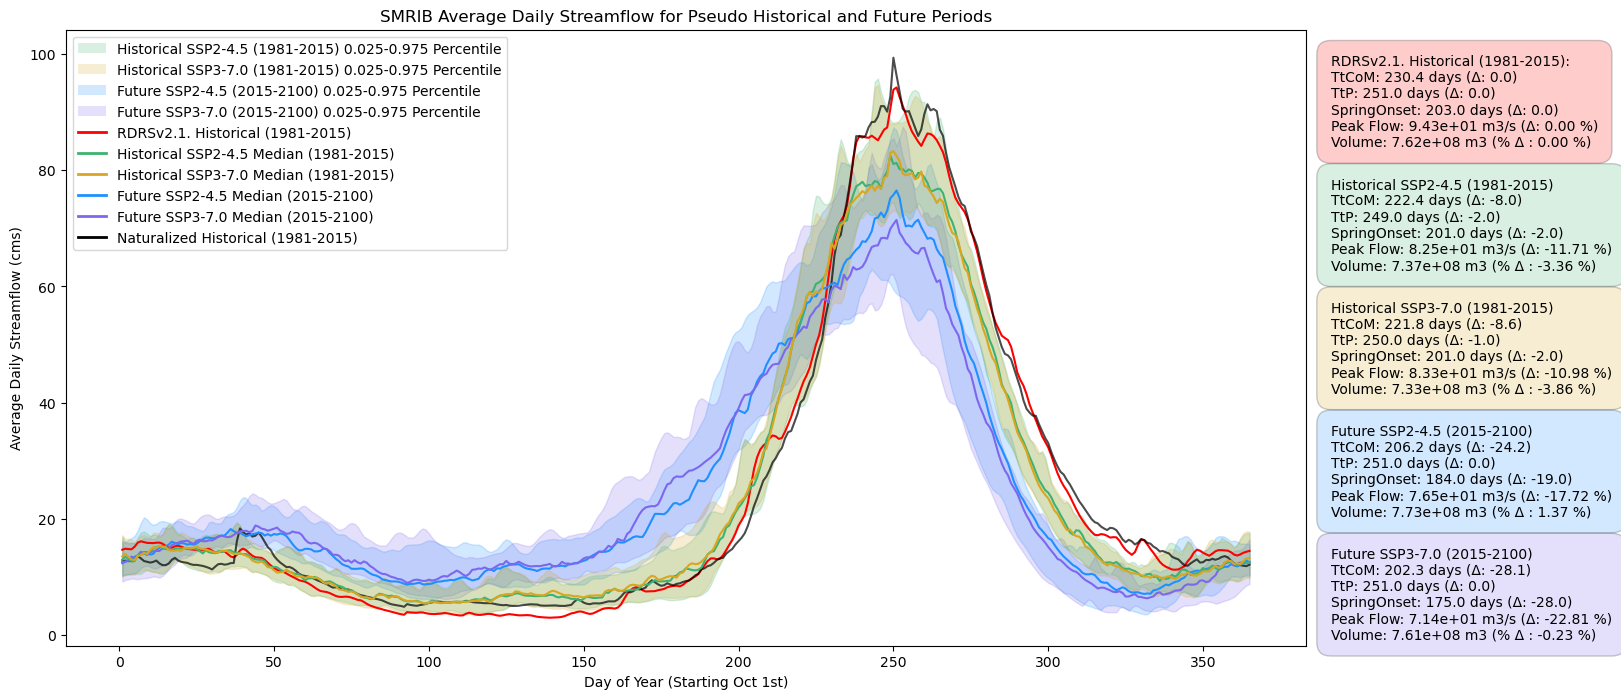

In [32]:
# Set the figure size
plt.figure(figsize=(16, 8))  # Adjust width and height as needed

# Define colors for ensembles
future_color1 = 'dodgerblue'
future_color2 = 'mediumslateblue'
historical_color1 = 'mediumseagreen'
historical_color2 = 'goldenrod'
historical_forcing_color = 'red'
historical_obs_color = 'black'  # New color for observed historical

# Plot the historical trace
smrib_historical.plot(label='RDRSv2.1. Historical', color=historical_forcing_color)
if variable == 'cout':  # Only plot observed historical if variable is 'cout'
    smrib_obs_historical.plot(label='Observed Historical', color=historical_obs_color, alpha=0.7)

# Fill between lines for each ensemble using 2.5th and 97.5th percentiles
plt.fill_between(
    smrib_ssp245['dayofyear'],
    smrib_ssp245.quantile(0.025, dim='member'),
    smrib_ssp245.quantile(0.975, dim='member'),
    color=future_color1,
    alpha=0.2
)
plt.fill_between(
    smrib_ssp370['dayofyear'],
    smrib_ssp370.quantile(0.025, dim='member'),
    smrib_ssp370.quantile(0.975, dim='member'),
    color=future_color2,
    alpha=0.2
)
plt.fill_between(
    smrib_hist_ssp245['dayofyear'],
    smrib_hist_ssp245.quantile(0.025, dim='member'),
    smrib_hist_ssp245.quantile(0.975, dim='member'),
    color=historical_color1,
    alpha=0.2
)
plt.fill_between(
    smrib_hist_ssp370['dayofyear'],
    smrib_hist_ssp370.quantile(0.025, dim='member'),
    smrib_hist_ssp370.quantile(0.975, dim='member'),
    color=historical_color2,
    alpha=0.2
)

# Calculate and plot the median of each ensemble
ens1_median = smrib_ssp245.median(dim='member')
ens2_median = smrib_ssp370.median(dim='member')
ens3_median = smrib_hist_ssp245.median(dim='member')
ens4_median = smrib_hist_ssp370.median(dim='member')

historical_stats, empty = compute_hydrologic_metrics(smrib_historical)
ens1_stats, ens1_diff = compute_hydrologic_metrics(ens1_median, historical=historical_stats)
ens2_stats, ens2_diff = compute_hydrologic_metrics(ens2_median, historical=historical_stats)
ens3_stats, ens3_diff = compute_hydrologic_metrics(ens3_median, historical=historical_stats)
ens4_stats, ens4_diff = compute_hydrologic_metrics(ens4_median, historical=historical_stats)

ens1_median.plot(color=future_color1, linestyle='-', label='Future SSP2-4.5 (2015-2100)')
ens2_median.plot(color=future_color2, linestyle='-', label='Future SSP3-7.0 (2015-2100)')
ens3_median.plot(color=historical_color1, linestyle='-', label='Historical SSP2-4.5 (1981-2015)')
ens4_median.plot(color=historical_color2, linestyle='-', label='Historical SSP3-7.0 (1981-2015)')

# Manually create legend handles and labels
legend_handles = [
    Patch(facecolor=historical_color1, alpha=0.2, label='Historical SSP2-4.5 (1981-2015) 0.025-0.975 Percentile'),
    Patch(facecolor=historical_color2, alpha=0.2, label='Historical SSP3-7.0 (1981-2015) 0.025-0.975 Percentile'),
    Patch(facecolor=future_color1, alpha=0.2, label='Future SSP2-4.5 (2015-2100) 0.025-0.975 Percentile'),
    Patch(facecolor=future_color2, alpha=0.2, label='Future SSP3-7.0 (2015-2100) 0.025-0.975 Percentile'),
 #   Line2D([0], [0], color=historical_obs_color, lw=2, label='Naturalized Historical (1981-2015)'),  # New legend for observed historical
    Line2D([0], [0], color=historical_forcing_color, lw=2, label='RDRSv2.1. Historical (1981-2015)'),
    Line2D([0], [0], color=historical_color1, lw=2, linestyle='-', label='Historical SSP2-4.5 Median (1981-2015)'),
    Line2D([0], [0], color=historical_color2, lw=2, linestyle='-', label='Historical SSP3-7.0 Median (1981-2015)'),
    Line2D([0], [0], color=future_color1, lw=2, linestyle='-', label='Future SSP2-4.5 Median (2015-2100)'),
    Line2D([0], [0], color=future_color2, lw=2, linestyle='-', label='Future SSP3-7.0 Median (2015-2100)')
]
# Only add the black legend item if variable == 'cout'
if variable == 'cout':
    legend_handles.append(Line2D([0], [0], color=historical_obs_color, lw=2, label='Naturalized Historical (1981-2015)'))


# Add legend with custom handles and labels
plt.legend(handles=legend_handles)

# Customize labels and title
plt.xlabel('Day of Year (Starting Oct 1st)')
plt.ylabel(f'Average Daily {variable_name} ({variable_unit})')
plt.title(f'SMRIB Average Daily {variable_name} for Pseudo Historical and Future Periods')

# Set the position of the annotation boxes
x_pos = 1.02  # x-position for the annotation box
y_offset = 0.96  # Start Y position

for stats, diff, label, color in [
    (historical_stats, (0, 0, 0, 0, 0), 'RDRSv2.1. Historical (1981-2015):', historical_forcing_color),
    (ens3_stats, ens3_diff, 'Historical SSP2-4.5 (1981-2015)', historical_color1),
    (ens4_stats, ens4_diff, 'Historical SSP3-7.0 (1981-2015)', historical_color2),
    (ens1_stats, ens1_diff, 'Future SSP2-4.5 (2015-2100)', future_color1),
    (ens2_stats, ens2_diff, 'Future SSP3-7.0 (2015-2100)', future_color2)
]:
    ttcom, ttp, spring_pulse_onset, peak_flow, total_volume = stats
    d_ttcom, d_ttp, d_spring_pulse_onset, d_peak_flow, d_total_volume = diff  # Extract differences

    annotation = (
        f"{label}\n"
        f"TtCoM: {ttcom:.1f} days (Δ: {d_ttcom:.1f})\n"
        f"TtP: {ttp:.1f} days (Δ: {d_ttp:.1f})\n"
        f"SpringOnset: {spring_pulse_onset:.1f} days (Δ: {d_spring_pulse_onset:.1f})\n"
        f"Peak Flow: {peak_flow:.2e} m3/s (Δ: {d_peak_flow:.2f} %)\n"
        f"Volume: {total_volume:.2e} m3 (% Δ : {d_total_volume:.2f} %)"
    )

    plt.text(
        x_pos, y_offset, annotation, transform=plt.gca().transAxes,
        fontsize=10, verticalalignment='top', horizontalalignment='left',
        bbox=dict(facecolor=color, alpha=0.2, boxstyle='round,pad=1')
    )
    y_offset -= 0.2  # Adjust y_offset for the next box

# Save the plot to the output directory
file_path_allssp = os.path.join(output_directory, f'SMRIB_hist_future_average_annual_{variable}.png')
plt.savefig(file_path_allssp)
plt.show()

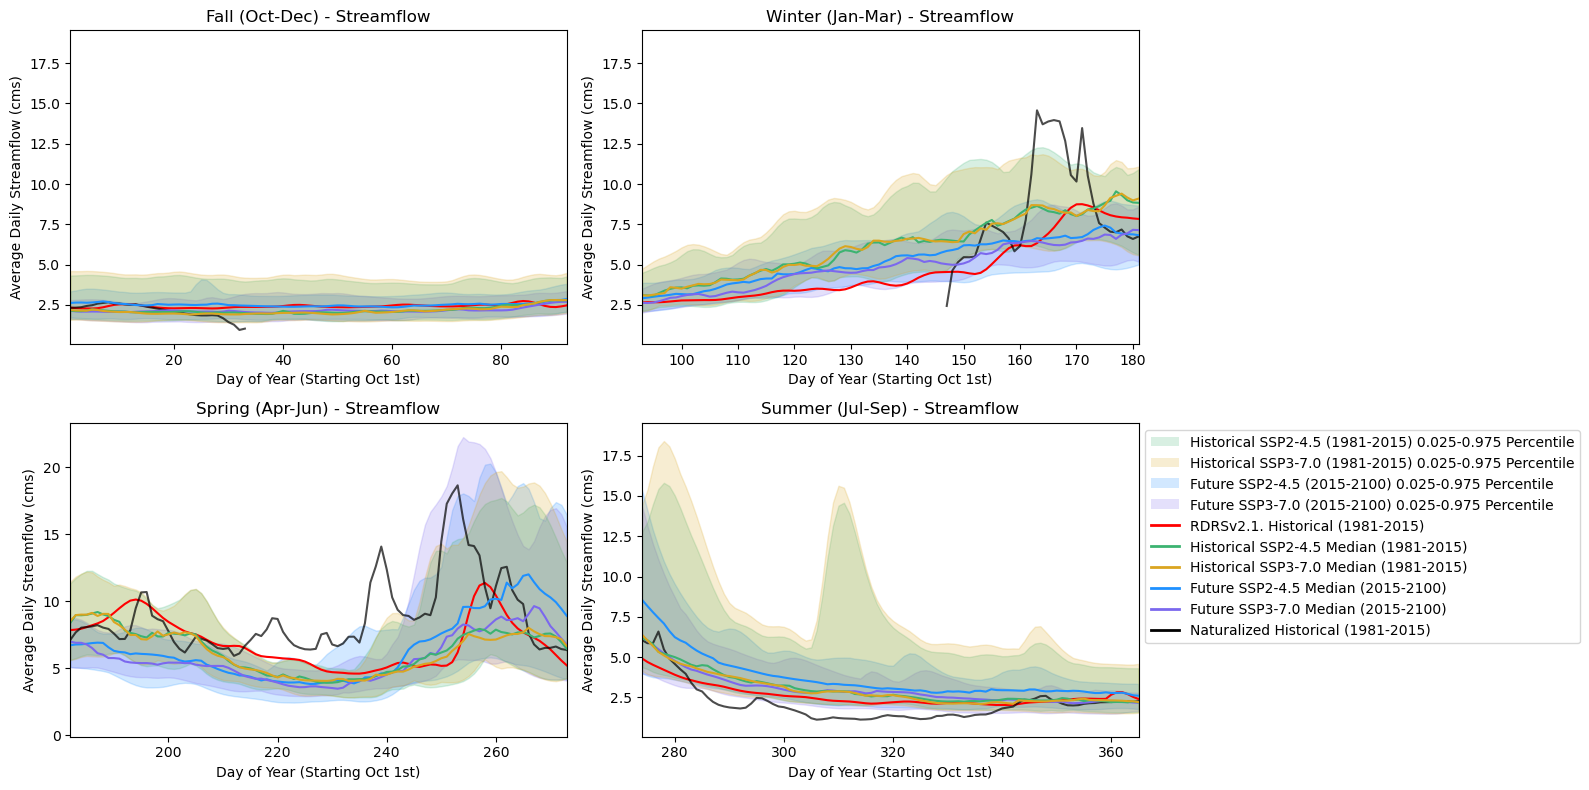

In [33]:
# Define the figure and axes for 4 subplots (one for each season)
fig, axes = plt.subplots(2, 2, figsize=(16, 8))  # 2x2 grid of subplots
axes = axes.flatten()  # Flatten the 2D axes array for easier indexing

# Define colors for ensembles
future_color1 = 'dodgerblue'
future_color2 = 'mediumslateblue'
historical_color1 = 'mediumseagreen'
historical_color2 = 'goldenrod'
historical_forcing_color = 'red'
historical_obs_color = 'black'  # New color for observed historical

# Define seasons with day-of-year ranges
seasons = {
    "Fall (Oct-Dec)": (1, 92),
    "Winter (Jan-Mar)": (93, 181),
    "Spring (Apr-Jun)": (182, 273),
    "Summer (Jul-Sep)": (274, 365)
}

# Loop over each season to create a subplot for each
for i, (season_name, (start_day, end_day)) in enumerate(seasons.items()):
    ax = axes[i]  # Get the corresponding axis for the subplot
    
    # Plot the historical trace
    mreib_historical.plot(label='RDRSv2.1. Historical', color=historical_forcing_color, ax=ax)
    if variable == 'cout':  # Only plot observed historical if variable is 'cout'
        mreib_obs_historical.plot(label='Observed Historical', color=historical_obs_color, alpha=0.7, ax=ax)

    # Filter the data for the current season (day-of-year range)
    mreib_ssp245_season = mreib_ssp245.sel(dayofyear=slice(start_day, end_day))
    mreib_ssp370_season = mreib_ssp370.sel(dayofyear=slice(start_day, end_day))
    mreib_hist_ssp245_season = mreib_hist_ssp245.sel(dayofyear=slice(start_day, end_day))
    mreib_hist_ssp370_season = mreib_hist_ssp370.sel(dayofyear=slice(start_day, end_day))

    # Fill between lines for each ensemble using 2.5th and 97.5th percentiles
    ax.fill_between(
        mreib_ssp245_season['dayofyear'],
        mreib_ssp245_season.quantile(0.025, dim='member'),
        mreib_ssp245_season.quantile(0.975, dim='member'),
        color=future_color1,
        alpha=0.2
    )
    ax.fill_between(
        mreib_ssp370_season['dayofyear'],
        mreib_ssp370_season.quantile(0.025, dim='member'),
        mreib_ssp370_season.quantile(0.975, dim='member'),
        color=future_color2,
        alpha=0.2
    )
    ax.fill_between(
        mreib_hist_ssp245_season['dayofyear'],
        mreib_hist_ssp245_season.quantile(0.025, dim='member'),
        mreib_hist_ssp245_season.quantile(0.975, dim='member'),
        color=historical_color1,
        alpha=0.2
    )
    ax.fill_between(
        mreib_hist_ssp370_season['dayofyear'],
        mreib_hist_ssp370_season.quantile(0.025, dim='member'),
        mreib_hist_ssp370_season.quantile(0.975, dim='member'),
        color=historical_color2,
        alpha=0.2
    )

    # Calculate and plot the median of each ensemble
    ens1_median_season = mreib_ssp245_season.median(dim='member')
    ens2_median_season = mreib_ssp370_season.median(dim='member')
    ens3_median_season = mreib_hist_ssp245_season.median(dim='member')
    ens4_median_season = mreib_hist_ssp370_season.median(dim='member')

    ens1_median_season.plot(color=future_color1, linestyle='-', label='Future SSP2-4.5 (2015-2100)', ax=ax)
    ens2_median_season.plot(color=future_color2, linestyle='-', label='Future SSP3-7.0 (2015-2100)', ax=ax)
    ens3_median_season.plot(color=historical_color1, linestyle='-', label='Historical SSP2-4.5 (1981-2015)', ax=ax)
    ens4_median_season.plot(color=historical_color2, linestyle='-', label='Historical SSP3-7.0 (1981-2015)', ax=ax)

    # Set the title, labels, and customize each subplot
    ax.set_title(f'{season_name} - {variable_name}')
    ax.set_xlabel('Day of Year (Starting Oct 1st)')
    ax.set_ylabel(f'Average Daily {variable_name} ({variable_unit})')
    
    # Customize the x-axis limits to the season's day-of-year range
    ax.set_xlim([start_day, end_day])

# Manually create legend handles and labels
legend_handles = [
    Patch(facecolor=historical_color1, alpha=0.2, label='Historical SSP2-4.5 (1981-2015) 0.025-0.975 Percentile'),
    Patch(facecolor=historical_color2, alpha=0.2, label='Historical SSP3-7.0 (1981-2015) 0.025-0.975 Percentile'),
    Patch(facecolor=future_color1, alpha=0.2, label='Future SSP2-4.5 (2015-2100) 0.025-0.975 Percentile'),
    Patch(facecolor=future_color2, alpha=0.2, label='Future SSP3-7.0 (2015-2100) 0.025-0.975 Percentile'),
    Line2D([0], [0], color=historical_forcing_color, lw=2, label='RDRSv2.1. Historical (1981-2015)'),
    Line2D([0], [0], color=historical_color1, lw=2, linestyle='-', label='Historical SSP2-4.5 Median (1981-2015)'),
    Line2D([0], [0], color=historical_color2, lw=2, linestyle='-', label='Historical SSP3-7.0 Median (1981-2015)'),
    Line2D([0], [0], color=future_color1, lw=2, linestyle='-', label='Future SSP2-4.5 Median (2015-2100)'),
    Line2D([0], [0], color=future_color2, lw=2, linestyle='-', label='Future SSP3-7.0 Median (2015-2100)')
]

# Only add the black legend item if variable == 'cout'
if variable == 'cout':
    legend_handles.append(Line2D([0], [0], color=historical_obs_color, lw=2, label='Naturalized Historical (1981-2015)'))

# Add legend with custom handles and labels, ensuring only one legend is shown
plt.legend(handles=legend_handles, loc='upper left', bbox_to_anchor=(1, 1))  # Move legend to the right, halfway down

# Customize the layout and show the plot
plt.tight_layout()

# Save the plot to the output directory
file_path_allssp = os.path.join(output_directory, f'MREIB_hist_future_seasons_{variable}.png')
plt.savefig(file_path_allssp)
plt.show()

### Updated Plots

In [59]:
def process_historical_with_percentiles(
    filepath: str, variable: str,
    start_date: str = '1981-01-01', end_date: str = '2015-12-31'
) -> tuple[pd.Series, pd.Series]:
    """
    Same pipeline as process_historical but returns (q25, q75) across years
    for each day of year, useful for shading interannual spread.
    """
    sim = pd.read_csv(filepath, delimiter='\t', index_col=0, low_memory=False)
    sim = sim.iloc[1:]
    sim = sim[[variable]]
    sim.index = pd.to_datetime(sim.index)
    sim = sim.loc[start_date:end_date]
    sim[variable] = pd.to_numeric(sim[variable], errors='coerce')
    # Replace -9999 values with NaN
    sim[variable] = sim[variable].replace(-9999, np.nan)  # np.nan instead of pd.NA

    grouped = sim.groupby(sim.index.dayofyear)[variable]
    q25 = grouped.quantile(0.25)
    q75 = grouped.quantile(0.75)

    for s in (q25, q75):
        s.drop(index=366, errors='ignore', inplace=True)

    def shift_index(s):
        shifted_idx = ((s.index - 274) % 365) + 1
        s.index = shifted_idx
        return s.sort_index()

    return shift_index(q25), shift_index(q75)

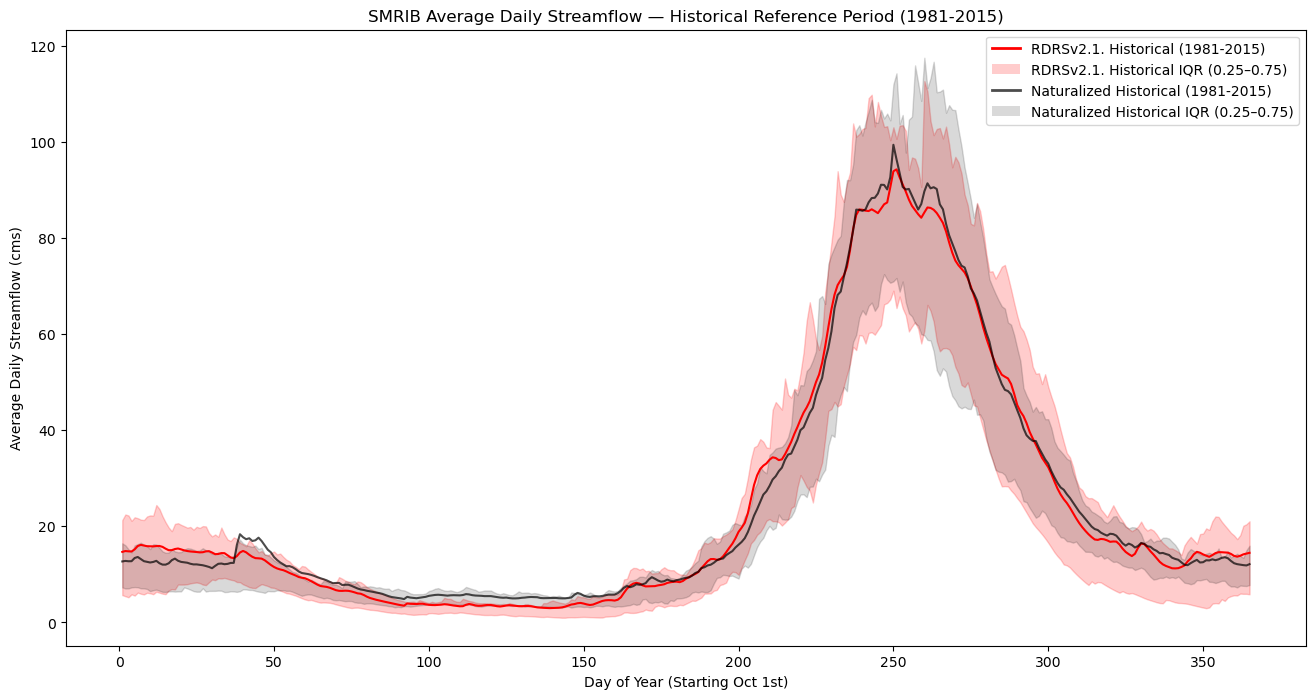

In [60]:
# Compute percentile bounds
smrib_hist_q25, smrib_hist_q75 = process_historical_with_percentiles(
    smrib_historical_path, variable
)

if variable == 'cout':
    smrib_obs_q25, smrib_obs_q75 = process_historical_with_percentiles(
        smrib_historical_path, 'rout'
    )

plt.figure(figsize=(16, 8))

# RDRS historical mean + shading
smrib_historical.plot(color=historical_forcing_color, label='RDRSv2.1. Historical (1981-2015)')
plt.fill_between(
    smrib_hist_q25.index,
    smrib_hist_q25,
    smrib_hist_q75,
    color=historical_forcing_color,
    alpha=0.2,
    label='RDRSv2.1. Historical IQR (0.25–0.75)'
)

# Naturalized observed mean + shading (cout only)
if variable == 'cout':
    smrib_obs_historical.plot(color=historical_obs_color, alpha=0.7,
                              label='Naturalized Historical (1981-2015)')
    plt.fill_between(
        smrib_obs_q25.index,
        smrib_obs_q25,
        smrib_obs_q75,
        color=historical_obs_color,
        alpha=0.15,
        label='Naturalized Historical IQR (0.25–0.75)'
    )

# Legend
legend_handles = [
    Line2D([0], [0], color=historical_forcing_color, lw=2,
           label='RDRSv2.1. Historical (1981-2015)'),
    Patch(facecolor=historical_forcing_color, alpha=0.2,
          label='RDRSv2.1. Historical IQR (0.25–0.75)'),
]
if variable == 'cout':
    legend_handles += [
        Line2D([0], [0], color=historical_obs_color, lw=2, alpha=0.7,
               label='Naturalized Historical (1981-2015)'),
        Patch(facecolor=historical_obs_color, alpha=0.15,
              label='Naturalized Historical IQR (0.25–0.75)'),
    ]

plt.legend(handles=legend_handles)
plt.xlabel('Day of Year (Starting Oct 1st)')
plt.ylabel(f'Average Daily {variable_name} ({variable_unit})')
plt.title(f'SMRIB Average Daily {variable_name} — Historical Reference Period (1981-2015)')

file_path = os.path.join(output_directory, f'SMRIB_historical_only_{variable}.png')
plt.savefig(file_path, bbox_inches='tight')
plt.show()

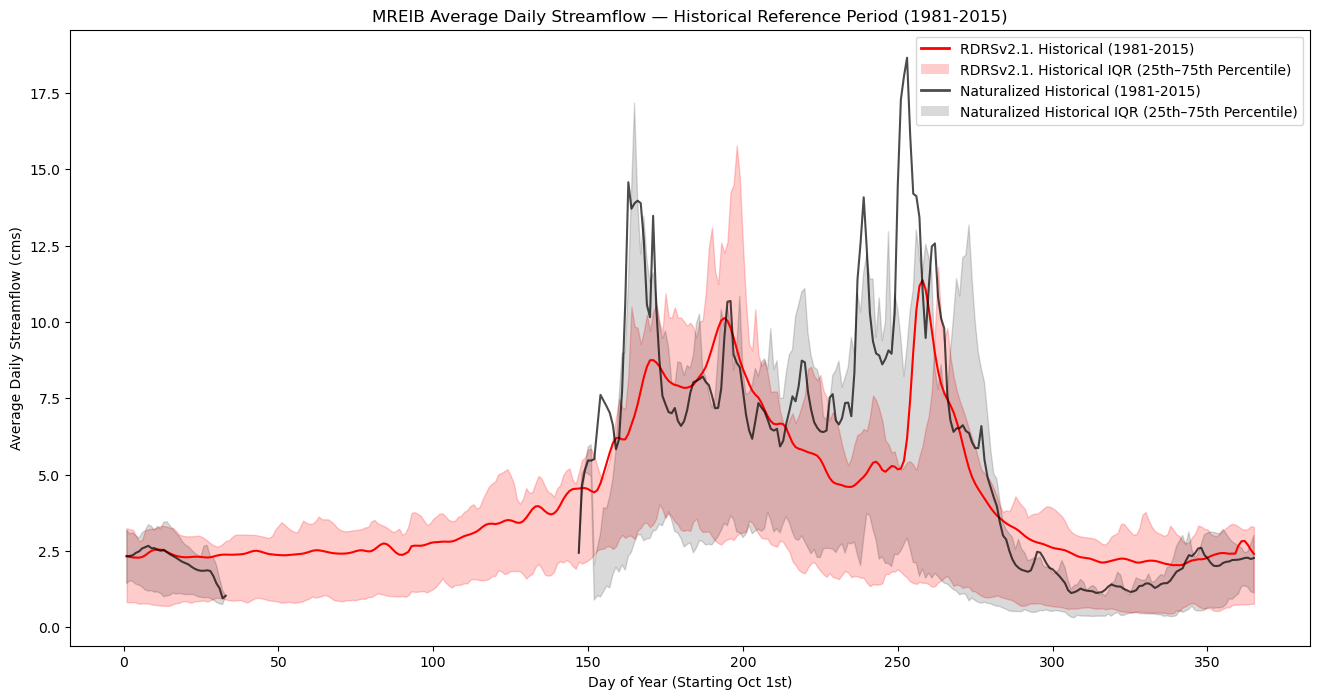

In [61]:
# Compute percentile bounds
mreib_hist_q25, mreib_hist_q75 = process_historical_with_percentiles(
    mreib_historical_path, variable
)
if variable == 'cout':
    mreib_obs_q25, mreib_obs_q75 = process_historical_with_percentiles(
        mreib_historical_path, 'rout'
    )

plt.figure(figsize=(16, 8))

# RDRS historical mean + shading
mreib_historical.plot(color=historical_forcing_color, label='RDRSv2.1. Historical (1981-2015)')
plt.fill_between(
    mreib_hist_q25.index,
    mreib_hist_q25,
    mreib_hist_q75,
    color=historical_forcing_color,
    alpha=0.2,
    label='RDRSv2.1. Historical IQR (25th–75th Percentile)'
)

# Naturalized observed mean + shading (cout only)
if variable == 'cout':
    mreib_obs_historical.plot(color=historical_obs_color, alpha=0.7,
                              label='Naturalized Historical (1981-2015)')
    plt.fill_between(
        mreib_obs_q25.index,
        mreib_obs_q25,
        mreib_obs_q75,
        color=historical_obs_color,
        alpha=0.15,
        label='Naturalized Historical IQR (25th–75th Percentile)'
    )

# Legend
legend_handles = [
    Line2D([0], [0], color=historical_forcing_color, lw=2,
           label='RDRSv2.1. Historical (1981-2015)'),
    Patch(facecolor=historical_forcing_color, alpha=0.2,
          label='RDRSv2.1. Historical IQR (25th–75th Percentile)'),
]
if variable == 'cout':
    legend_handles += [
        Line2D([0], [0], color=historical_obs_color, lw=2, alpha=0.7,
               label='Naturalized Historical (1981-2015)'),
        Patch(facecolor=historical_obs_color, alpha=0.15,
              label='Naturalized Historical IQR (25th–75th Percentile)'),
    ]

plt.legend(handles=legend_handles)
plt.xlabel('Day of Year (Starting Oct 1st)')
plt.ylabel(f'Average Daily {variable_name} ({variable_unit})')
plt.title(f'MREIB Average Daily {variable_name} — Historical Reference Period (1981-2015)')

file_path = os.path.join(output_directory, f'MREIB_historical_only_{variable}.png')
plt.savefig(file_path, bbox_inches='tight')
plt.show()

In [62]:
mreib_hist_ssp245

<xarray.DataArray (member: 15, dayofyear: 365)> Size: 44kB
array([[1.57994286, 1.59288571, 1.6102    , ..., 1.5608    , 1.562     ,
        1.56825714],
       [5.20814286, 5.213     , 5.22797143, ..., 5.20228571, 5.20131429,
        5.20217143],
       [2.67005714, 2.69608571, 2.71517143, ..., 2.67065714, 2.65557143,
        2.65431429],
       ...,
       [1.69722857, 1.71257143, 1.69562857, ..., 1.6004    , 1.60731429,
        1.6492    ],
       [2.02165714, 2.0246    , 2.01322857, ..., 1.91268571, 1.96477143,
        2.00377143],
       [2.47937143, 2.28788571, 2.08594286, ..., 2.06231429, 2.37365714,
        2.5416    ]])
Coordinates:
    variable   <U4 16B 'cout'
  * dayofyear  (dayofyear) int64 3kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
Dimensions without coordinates: member

### Delta Analysis

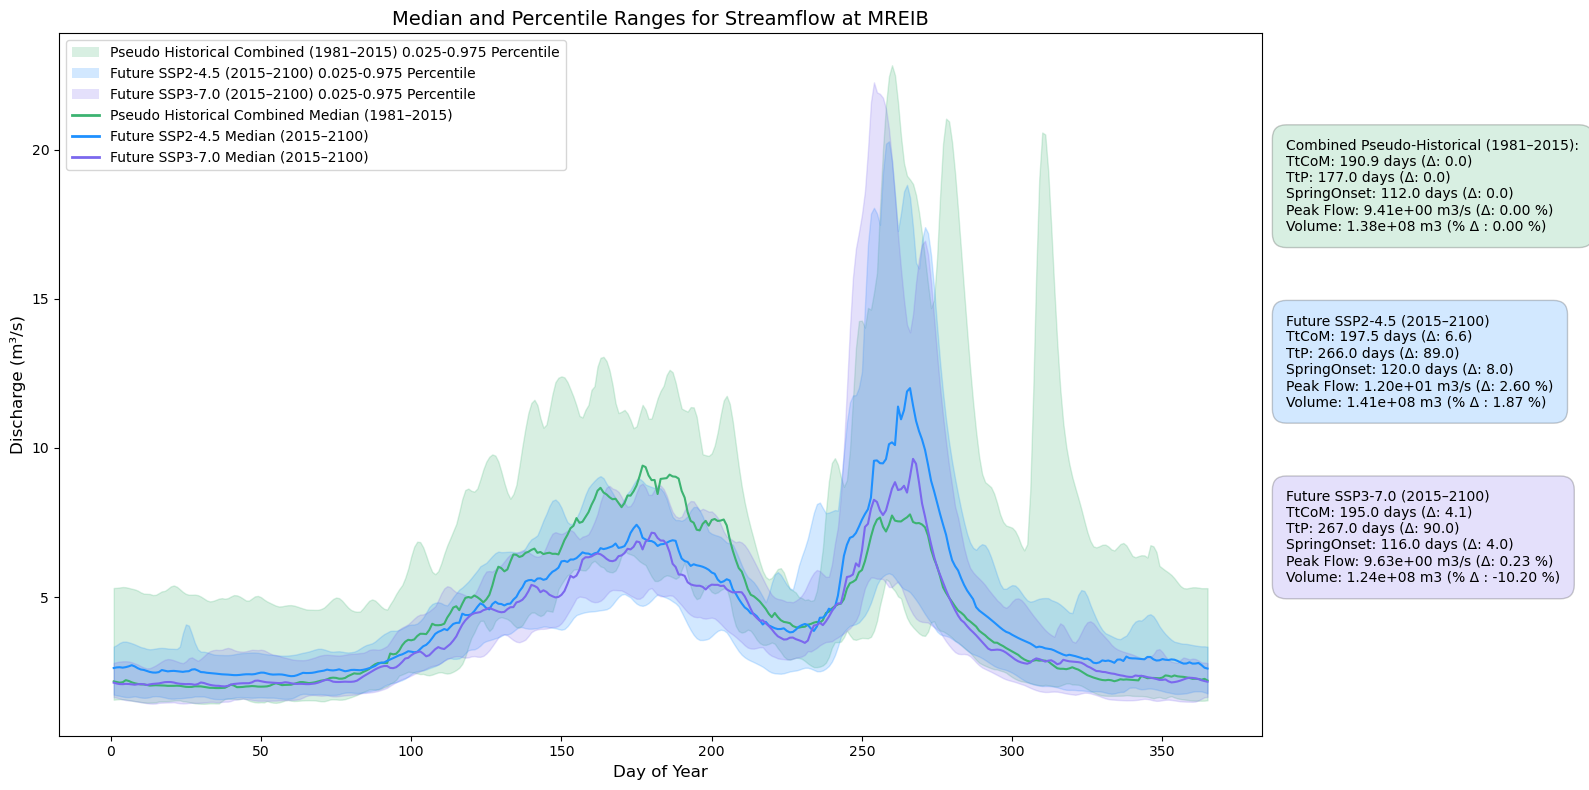

In [34]:
# Combine the historical ensembles
mreib_hist_combined = xr.concat([mreib_hist_ssp245, mreib_hist_ssp370], dim='member')

plt.figure(figsize=(16, 8))  # Match the layout size

# Compute medians
ens_hist_median = mreib_hist_combined.median(dim='member')
ens1_median = mreib_ssp245.median(dim='member')
ens2_median = mreib_ssp370.median(dim='member')

# Compute stats using the median of the combined historical
historical_stats, empty = compute_hydrologic_metrics(ens_hist_median)
ens1_stats, ens1_diff = compute_hydrologic_metrics(ens1_median, historical=historical_stats)
ens2_stats, ens2_diff = compute_hydrologic_metrics(ens2_median, historical=historical_stats)

# Plot shading for percentile bands
plt.fill_between(
    mreib_hist_combined['dayofyear'],
    mreib_hist_combined.quantile(0.025, dim='member'),
    mreib_hist_combined.quantile(0.975, dim='member'),
    color=historical_color1,
    alpha=0.2
)
plt.fill_between(
    mreib_ssp245['dayofyear'],
    mreib_ssp245.quantile(0.025, dim='member'),
    mreib_ssp245.quantile(0.975, dim='member'),
    color=future_color1,
    alpha=0.2
)
plt.fill_between(
    mreib_ssp370['dayofyear'],
    mreib_ssp370.quantile(0.025, dim='member'),
    mreib_ssp370.quantile(0.975, dim='member'),
    color=future_color2,
    alpha=0.2
)

# Plot median lines
ens_hist_median.plot(color=historical_color1, linestyle='-', label='Pseudo Historical Combined Median (1981-2015)')
ens1_median.plot(color=future_color1, linestyle='-', label='Future SSP2-4.5 Median (2015-2100)')
ens2_median.plot(color=future_color2, linestyle='-', label='Future SSP3-7.0 Median (2015-2100)')

# Update legend
legend_handles = [
    Patch(facecolor=historical_color1, alpha=0.2, label='Pseudo Historical Combined (1981–2015) 0.025-0.975 Percentile'),
    Patch(facecolor=future_color1, alpha=0.2, label='Future SSP2-4.5 (2015–2100) 0.025-0.975 Percentile'),
    Patch(facecolor=future_color2, alpha=0.2, label='Future SSP3-7.0 (2015–2100) 0.025-0.975 Percentile'),
    Line2D([0], [0], color=historical_color1, lw=2, linestyle='-', label='Pseudo Historical Combined Median (1981–2015)'),
    Line2D([0], [0], color=future_color1, lw=2, linestyle='-', label='Future SSP2-4.5 Median (2015–2100)'),
    Line2D([0], [0], color=future_color2, lw=2, linestyle='-', label='Future SSP3-7.0 Median (2015–2100)')
]


plt.legend(handles=legend_handles)

# Update annotations (3 instead of 5)
x_pos = 1.02
y_offset = 0.85

for stats, diff, label, color in [
    (historical_stats, (0, 0, 0, 0, 0), 'Combined Pseudo-Historical (1981–2015):', historical_color1),
    (ens1_stats, ens1_diff, 'Future SSP2-4.5 (2015–2100)', future_color1),
    (ens2_stats, ens2_diff, 'Future SSP3-7.0 (2015–2100)', future_color2)
]:
    ttcom, ttp, spring_pulse_onset, peak_flow, total_volume = stats
    d_ttcom, d_ttp, d_spring_pulse_onset, d_peak_flow, d_total_volume = diff

    annotation = (
        f"{label}\n"
        f"TtCoM: {ttcom:.1f} days (Δ: {d_ttcom:.1f})\n"
        f"TtP: {ttp:.1f} days (Δ: {d_ttp:.1f})\n"
        f"SpringOnset: {spring_pulse_onset:.1f} days (Δ: {d_spring_pulse_onset:.1f})\n"
        f"Peak Flow: {peak_flow:.2e} m3/s (Δ: {d_peak_flow:.2f} %)\n"
        f"Volume: {total_volume:.2e} m3 (% Δ : {d_total_volume:.2f} %)"
    )

    plt.text(
        x_pos, y_offset, annotation, transform=plt.gca().transAxes,
        fontsize=10, verticalalignment='top', horizontalalignment='left',
        bbox=dict(facecolor=color, alpha=0.2, boxstyle='round,pad=1')
    )
    y_offset -= 0.25
    
plt.title(f'Median and Percentile Ranges for {variable_name} at MREIB', fontsize=14)
plt.xlabel('Day of Year', fontsize=12)
plt.ylabel('Discharge (m³/s)', fontsize=12)

# Save and show
file_path_allssp = os.path.join(output_directory, f'MREIB_hist_future_combined_{variable}.png')
plt.tight_layout()
plt.savefig(file_path_allssp)
plt.show()

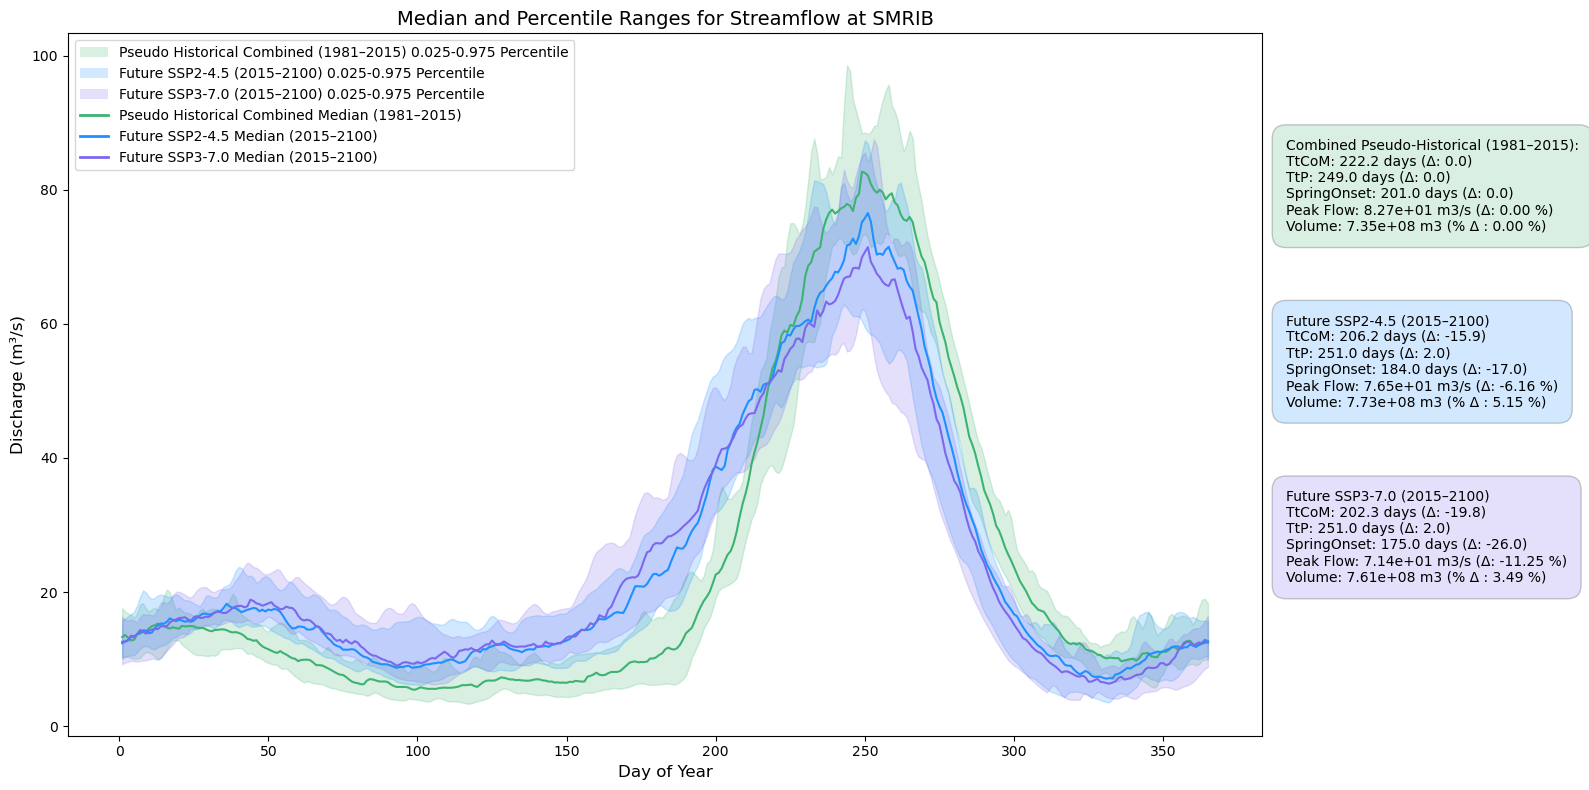

In [35]:
# Combine the historical ensembles
smrib_hist_combined = xr.concat([smrib_hist_ssp245, smrib_hist_ssp370], dim='member')

plt.figure(figsize=(16, 8))  # Match the layout size

# Compute medians
ens_hist_median = smrib_hist_combined.median(dim='member')
ens1_median = smrib_ssp245.median(dim='member')
ens2_median = smrib_ssp370.median(dim='member')

# Compute stats using the median of the combined historical
historical_stats, empty = compute_hydrologic_metrics(ens_hist_median)
ens1_stats, ens1_diff = compute_hydrologic_metrics(ens1_median, historical=historical_stats)
ens2_stats, ens2_diff = compute_hydrologic_metrics(ens2_median, historical=historical_stats)

# Plot shading for percentile bands
plt.fill_between(
    smrib_hist_combined['dayofyear'],
    smrib_hist_combined.quantile(0.025, dim='member'),
    smrib_hist_combined.quantile(0.975, dim='member'),
    color=historical_color1,
    alpha=0.2
)
plt.fill_between(
    smrib_ssp245['dayofyear'],
    smrib_ssp245.quantile(0.025, dim='member'),
    smrib_ssp245.quantile(0.975, dim='member'),
    color=future_color1,
    alpha=0.2
)
plt.fill_between(
    smrib_ssp370['dayofyear'],
    smrib_ssp370.quantile(0.025, dim='member'),
    smrib_ssp370.quantile(0.975, dim='member'),
    color=future_color2,
    alpha=0.2
)

# Plot median lines
ens_hist_median.plot(color=historical_color1, linestyle='-', label='Pseudo Historical Combined Median (1981-2015)')
ens1_median.plot(color=future_color1, linestyle='-', label='Future SSP2-4.5 Median (2015-2100)')
ens2_median.plot(color=future_color2, linestyle='-', label='Future SSP3-7.0 Median (2015-2100)')

# Update legend
legend_handles = [
    Patch(facecolor=historical_color1, alpha=0.2, label='Pseudo Historical Combined (1981–2015) 0.025-0.975 Percentile'),
    Patch(facecolor=future_color1, alpha=0.2, label='Future SSP2-4.5 (2015–2100) 0.025-0.975 Percentile'),
    Patch(facecolor=future_color2, alpha=0.2, label='Future SSP3-7.0 (2015–2100) 0.025-0.975 Percentile'),
    Line2D([0], [0], color=historical_color1, lw=2, linestyle='-', label='Pseudo Historical Combined Median (1981–2015)'),
    Line2D([0], [0], color=future_color1, lw=2, linestyle='-', label='Future SSP2-4.5 Median (2015–2100)'),
    Line2D([0], [0], color=future_color2, lw=2, linestyle='-', label='Future SSP3-7.0 Median (2015–2100)')
]

plt.legend(handles=legend_handles)

# Update annotations (3 instead of 5)
x_pos = 1.02
y_offset = 0.85

for stats, diff, label, color in [
    (historical_stats, (0, 0, 0, 0, 0), 'Combined Pseudo-Historical (1981–2015):', historical_color1),
    (ens1_stats, ens1_diff, 'Future SSP2-4.5 (2015–2100)', future_color1),
    (ens2_stats, ens2_diff, 'Future SSP3-7.0 (2015–2100)', future_color2)
]:
    ttcom, ttp, spring_pulse_onset, peak_flow, total_volume = stats
    d_ttcom, d_ttp, d_spring_pulse_onset, d_peak_flow, d_total_volume = diff

    annotation = (
        f"{label}\n"
        f"TtCoM: {ttcom:.1f} days (Δ: {d_ttcom:.1f})\n"
        f"TtP: {ttp:.1f} days (Δ: {d_ttp:.1f})\n"
        f"SpringOnset: {spring_pulse_onset:.1f} days (Δ: {d_spring_pulse_onset:.1f})\n"
        f"Peak Flow: {peak_flow:.2e} m3/s (Δ: {d_peak_flow:.2f} %)\n"
        f"Volume: {total_volume:.2e} m3 (% Δ : {d_total_volume:.2f} %)"
    )

    plt.text(
        x_pos, y_offset, annotation, transform=plt.gca().transAxes,
        fontsize=10, verticalalignment='top', horizontalalignment='left',
        bbox=dict(facecolor=color, alpha=0.2, boxstyle='round,pad=1')
    )
    y_offset -= 0.25
    
plt.title(f'Median and Percentile Ranges for {variable_name} at SMRIB', fontsize=14)
plt.xlabel('Day of Year', fontsize=12)
plt.ylabel('Discharge (m³/s)', fontsize=12)

# Save and show
file_path_allssp = os.path.join(output_directory, f'SMRIB_hist_future_combined_{variable}.png')
plt.tight_layout()
plt.savefig(file_path_allssp)
plt.show()


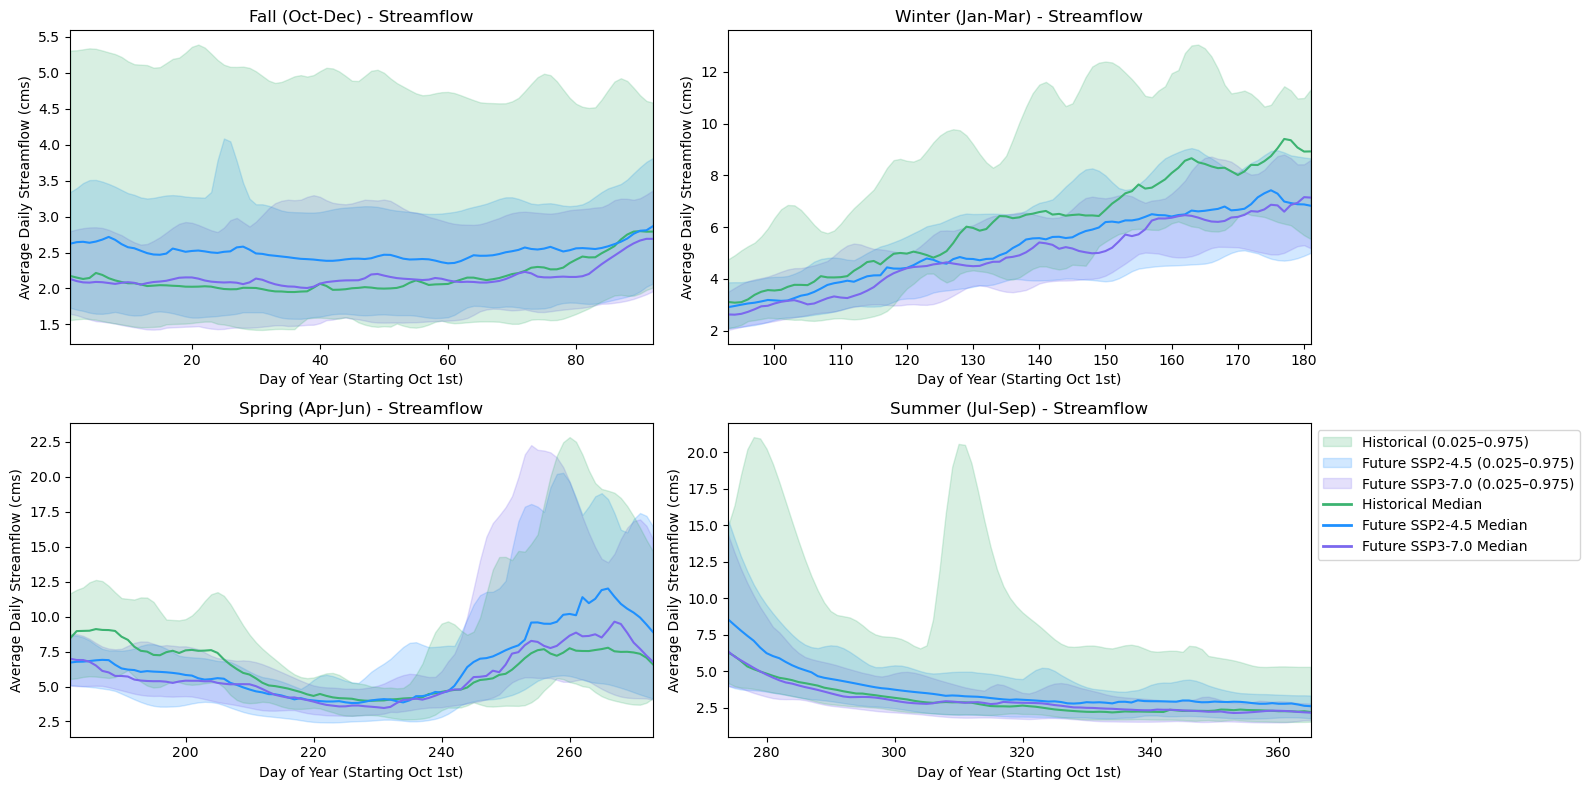

In [36]:
# Define the figure and axes for 4 subplots (one for each season)
fig, axes = plt.subplots(2, 2, figsize=(16, 8))  # 2x2 grid of subplots
axes = axes.flatten()  # Flatten the 2D axes array for easier indexing

# Define colors for ensembles
future_color1 = 'dodgerblue'
future_color2 = 'mediumslateblue'
historical_color1 = 'mediumseagreen'
historical_color2 = 'goldenrod'
historical_forcing_color = 'red'
historical_obs_color = 'black'  # New color for observed historical

# Define seasons with day-of-year ranges
seasons = {
    "Fall (Oct-Dec)": (1, 92),
    "Winter (Jan-Mar)": (93, 181),
    "Spring (Apr-Jun)": (182, 273),
    "Summer (Jul-Sep)": (274, 365)
}

# Loop over each season to create a subplot for each
for i, (season_name, (start_day, end_day)) in enumerate(seasons.items()):
    ax = axes[i]  # Get the corresponding axis for the subplot

    # Filter the data for the current season (day-of-year range)
    merib_ssp245_season = mreib_ssp245.sel(dayofyear=slice(start_day, end_day))
    merib_ssp370_season = mreib_ssp370.sel(dayofyear=slice(start_day, end_day))
    merib_hist_combined_season = mreib_hist_combined.sel(dayofyear=slice(start_day, end_day))

    # Fill between lines for each ensemble using 2.5th and 97.5th percentiles
    ax.fill_between(
        merib_ssp245_season['dayofyear'],
        merib_ssp245_season.quantile(0.025, dim='member'),
        merib_ssp245_season.quantile(0.975, dim='member'),
        color=future_color1,
        alpha=0.2
    )
    ax.fill_between(
        merib_ssp370_season['dayofyear'],
        merib_ssp370_season.quantile(0.025, dim='member'),
        merib_ssp370_season.quantile(0.975, dim='member'),
        color=future_color2,
        alpha=0.2
    )
    # Percentile bounds (combined historical)
    ax.fill_between(merib_hist_combined_season['dayofyear'],
                    merib_hist_combined_season.quantile(0.025, dim='member'),
                    merib_hist_combined_season.quantile(0.975, dim='member'),
                    color=historical_color1, alpha=0.2)

    # Calculate and plot the median of each ensemble
    hist_median_season = merib_hist_combined_season.median(dim='member')
    ens1_median_season = merib_ssp245_season.median(dim='member')
    ens2_median_season = merib_ssp370_season.median(dim='member')
    
    # Plot all medians
    hist_median_season.plot(color=historical_color1, linestyle='-', label='Historical Median', ax=ax)
    ens1_median_season.plot(color=future_color1, linestyle='-', label='Future SSP2-4.5 (2015-2100)', ax=ax)
    ens2_median_season.plot(color=future_color2, linestyle='-', label='Future SSP3-7.0 (2015-2100)', ax=ax)
    
    # Set the title, labels, and customize each subplot
    ax.set_title(f'{season_name} - {variable_name}')
    ax.set_xlabel('Day of Year (Starting Oct 1st)')
    ax.set_ylabel(f'Average Daily {variable_name} ({variable_unit})')
    
    # Customize the x-axis limits to the season's day-of-year range
    ax.set_xlim([start_day, end_day])

legend_handles = [
    Patch(color=historical_color1, alpha=0.2, label='Historical (0.025–0.975)'),
    Patch(color=future_color1, alpha=0.2, label='Future SSP2-4.5 (0.025–0.975)'),
    Patch(color=future_color2, alpha=0.2, label='Future SSP3-7.0 (0.025–0.975)'),
    Line2D([0], [0], color=historical_color1, lw=2, linestyle='-', label='Historical Median'),
    Line2D([0], [0], color=future_color1, lw=2, linestyle='-', label='Future SSP2-4.5 Median'),
    Line2D([0], [0], color=future_color2, lw=2, linestyle='-', label='Future SSP3-7.0 Median')
]

# Add legend with custom handles and labels, ensuring only one legend is shown
plt.legend(handles=legend_handles, loc='upper left', bbox_to_anchor=(1, 1))  # Move legend to the right, halfway down

# Customize the layout and show the plot
plt.tight_layout()

# Save the plot to the output directory
file_path_allssp = os.path.join(output_directory, f'MERIB_hist_future_seasons_{variable}.png')
plt.savefig(file_path_allssp)
plt.show()


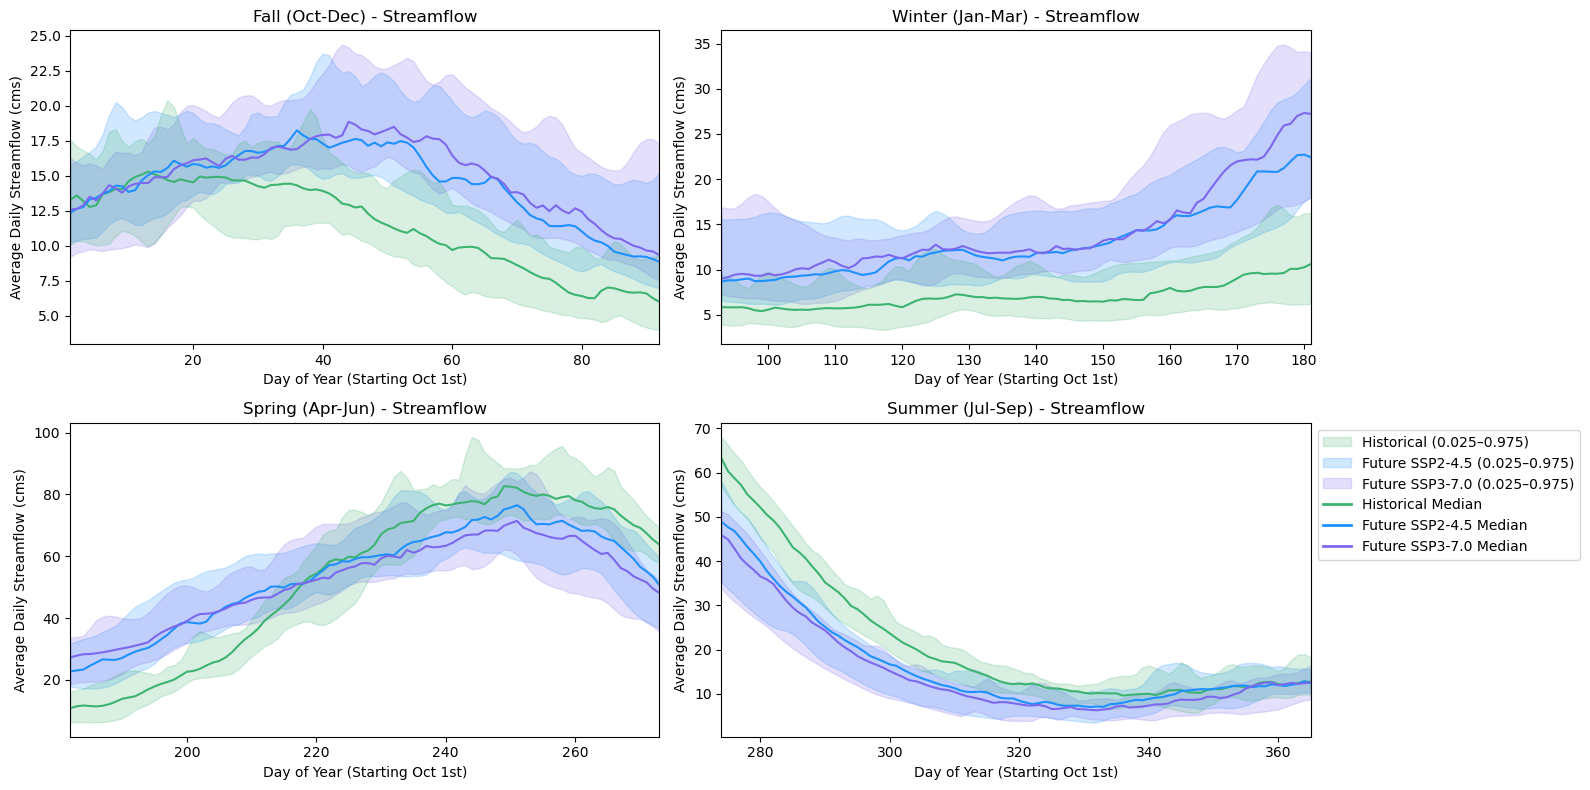

In [37]:
# Define the figure and axes for 4 subplots (one for each season)
fig, axes = plt.subplots(2, 2, figsize=(16, 8))  # 2x2 grid of subplots
axes = axes.flatten()  # Flatten the 2D axes array for easier indexing

# Define colors for ensembles
future_color1 = 'dodgerblue'
future_color2 = 'mediumslateblue'
historical_color1 = 'mediumseagreen'
historical_color2 = 'goldenrod'
historical_forcing_color = 'red'
historical_obs_color = 'black'  # New color for observed historical

# Define seasons with day-of-year ranges
seasons = {
    "Fall (Oct-Dec)": (1, 92),
    "Winter (Jan-Mar)": (93, 181),
    "Spring (Apr-Jun)": (182, 273),
    "Summer (Jul-Sep)": (274, 365)
}

# Loop over each season to create a subplot for each
for i, (season_name, (start_day, end_day)) in enumerate(seasons.items()):
    ax = axes[i]  # Get the corresponding axis for the subplot

    # Filter the data for the current season (day-of-year range)
    smrib_ssp245_season = smrib_ssp245.sel(dayofyear=slice(start_day, end_day))
    smrib_ssp370_season = smrib_ssp370.sel(dayofyear=slice(start_day, end_day))
    smrib_hist_combined_season = smrib_hist_combined.sel(dayofyear=slice(start_day, end_day))

    # Fill between lines for each ensemble using 2.5th and 97.5th percentiles
    ax.fill_between(
        smrib_ssp245_season['dayofyear'],
        smrib_ssp245_season.quantile(0.025, dim='member'),
        smrib_ssp245_season.quantile(0.975, dim='member'),
        color=future_color1,
        alpha=0.2
    )
    ax.fill_between(
        smrib_ssp370_season['dayofyear'],
        smrib_ssp370_season.quantile(0.025, dim='member'),
        smrib_ssp370_season.quantile(0.975, dim='member'),
        color=future_color2,
        alpha=0.2
    )
    # Percentile bounds (combined historical)
    ax.fill_between(smrib_hist_combined_season['dayofyear'],
                    smrib_hist_combined_season.quantile(0.025, dim='member'),
                    smrib_hist_combined_season.quantile(0.975, dim='member'),
                    color=historical_color1, alpha=0.2)

    # Calculate and plot the median of each ensemble
    hist_median_season = smrib_hist_combined_season.median(dim='member')
    ens1_median_season = smrib_ssp245_season.median(dim='member')
    ens2_median_season = smrib_ssp370_season.median(dim='member')
    
    # Plot all medians
    hist_median_season.plot(color=historical_color1, linestyle='-', label='Historical Median', ax=ax)
    ens1_median_season.plot(color=future_color1, linestyle='-', label='Future SSP2-4.5 (2015-2100)', ax=ax)
    ens2_median_season.plot(color=future_color2, linestyle='-', label='Future SSP3-7.0 (2015-2100)', ax=ax)
    
    # Set the title, labels, and customize each subplot
    ax.set_title(f'{season_name} - {variable_name}')
    ax.set_xlabel('Day of Year (Starting Oct 1st)')
    ax.set_ylabel(f'Average Daily {variable_name} ({variable_unit})')
    
    # Customize the x-axis limits to the season's day-of-year range
    ax.set_xlim([start_day, end_day])

legend_handles = [
    Patch(color=historical_color1, alpha=0.2, label='Historical (0.025–0.975)'),
    Patch(color=future_color1, alpha=0.2, label='Future SSP2-4.5 (0.025–0.975)'),
    Patch(color=future_color2, alpha=0.2, label='Future SSP3-7.0 (0.025–0.975)'),
    Line2D([0], [0], color=historical_color1, lw=2, linestyle='-', label='Historical Median'),
    Line2D([0], [0], color=future_color1, lw=2, linestyle='-', label='Future SSP2-4.5 Median'),
    Line2D([0], [0], color=future_color2, lw=2, linestyle='-', label='Future SSP3-7.0 Median')
]

# Add legend with custom handles and labels, ensuring only one legend is shown
plt.legend(handles=legend_handles, loc='upper left', bbox_to_anchor=(1, 1))  # Move legend to the right, halfway down

# Customize the layout and show the plot
plt.tight_layout()

# Save the plot to the output directory
file_path_allssp = os.path.join(output_directory, f'SMRIB_hist_future_seasons_{variable}.png')
plt.savefig(file_path_allssp)
plt.show()


### Statistics

In [38]:
def compute_nse(obs, sim):
    """Compute the Nash-Sutcliffe Efficiency (NSE)"""
    numerator = np.sum((obs - sim) ** 2)
    denominator = np.sum((obs - np.mean(obs)) ** 2)
    return 1 - (numerator / denominator)

# Compute NSE between the two historical ensembles
smrib_nse_value = compute_nse(smrib_hist_ssp245.median(dim='member'), smrib_hist_ssp370.median(dim='member'))

mreib_nse_value = compute_nse(mreib_hist_ssp245.median(dim='member'), mreib_hist_ssp370.median(dim='member'))

print(f'SMRIB Pseudo Hist NSE: {smrib_nse_value}\nMRIEB Pseudo Hist NSE" {mreib_nse_value}')

SMRIB Pseudo Hist NSE: <xarray.DataArray ()> Size: 8B
array(0.99919872)
Coordinates:
    variable  <U4 16B 'cout'
MRIEB Pseudo Hist NSE" <xarray.DataArray ()> Size: 8B
array(0.99435752)
Coordinates:
    variable  <U4 16B 'cout'


In [39]:
# Combine Pseudo hist data arrays
smrib_combined_hist = xr.concat([smrib_hist_ssp245, smrib_hist_ssp370], dim="member")
mreib_combined_hist = xr.concat([mreib_hist_ssp245, mreib_hist_ssp370], dim="member")

In [40]:
# Define metric names
metrics = ["TtCoM", "TtP", "Spring Pulse Onset", 'Peak Flow', "Total Volume"]

# Define units for each metric
units = ["days", "days", "days", 'cms', "m³"]

# Compute historical and future statistics
smrib_pseudo_historical_stats, empty = compute_hydrologic_metrics(smrib_combined_hist.median(dim='member'))
smrib_future_ens1_stats, smrib_future_ens1_diff = compute_hydrologic_metrics(smrib_ssp245.median(dim='member'), historical=smrib_pseudo_historical_stats)
smrib_future_ens2_stats, smrib_future_ens2_diff = compute_hydrologic_metrics(smrib_ssp370.median(dim='member'), historical=smrib_pseudo_historical_stats)

def format_value(val, diff, unit, metric):
    # If diff is zero, don't show the difference part
    if diff == 0:
        if unit == "days":
            return f"{int(val)} {unit}"
        elif unit == "m³":
            return f"{val:.2e} {unit}"  # Keeping in scientific notation for volume
        elif unit == "cms" and metric == "Peak Flow":
            return f"{val:.1f} {unit}"
    else:
        # If diff is non-zero, show the difference
        if unit == "days":
            return f"{int(val)} {unit} (Change of {int(diff)} {unit})"
        elif unit == "m³":
            if metric == "Total Volume":
                return f"{val:.2e} {unit} (Change of {diff:.2f}%)"  # Keeping non-scientific notation
            else:
                return f"{val:.2f} {unit} (Change of {diff:.2f} {unit})"
        elif unit == "cms" and metric == "Peak Flow":
            return f"{val:.1f} {unit} (Change of {diff:.2f} {unit})"

# Updated formatted_values for SMRIB and MREIB
formatted_values = {
    "Baseline (1981-2015)": [format_value(val, 0, unit, metric) for val, unit, metric in zip(smrib_pseudo_historical_stats, units, metrics)],
    "SSP245 (2015-2100)": [format_value(stat, diff, unit, metric) for stat, diff, unit, metric in zip(smrib_future_ens1_stats, smrib_future_ens1_diff, units, metrics)],
    "SSP370 (2015-2100)": [format_value(stat, diff, unit, metric) for stat, diff, unit, metric in zip(smrib_future_ens2_stats, smrib_future_ens2_diff, units, metrics)],
}

# Create DataFrame with formatted values for SMRIB
smrib_statistic_df = pd.DataFrame(formatted_values, index=metrics)

# Create the MultiIndex with both 'SMRIB' and 'MREIB' as the first level
# (This step is done later to avoid the error caused by the 'statistic_df.index' when combining)
mreib_pseudo_historical_stats, _ = compute_hydrologic_metrics(mreib_combined_hist.median(dim='member'))
mreib_future_ens1_stats, mreib_future_ens1_diff = compute_hydrologic_metrics(mreib_ssp245.median(dim='member'), historical=mreib_pseudo_historical_stats)
mreib_future_ens2_stats, mreib_future_ens2_diff = compute_hydrologic_metrics(mreib_ssp370.median(dim='member'), historical=mreib_pseudo_historical_stats)

# Similarly for MREIB
formatted_values_mreib = {
    "Baseline (1981-2015)": [format_value(val, 0, unit, metric) for val, unit, metric in zip(mreib_pseudo_historical_stats, units, metrics)],
    "SSP245 (2015-2100)": [format_value(stat, diff, unit, metric) for stat, diff, unit, metric in zip(mreib_future_ens1_stats, mreib_future_ens1_diff, units, metrics)],
    "SSP370 (2015-2100)": [format_value(stat, diff, unit, metric) for stat, diff, unit, metric in zip(mreib_future_ens2_stats, mreib_future_ens2_diff, units, metrics)],
}

# Create a DataFrame for MREIB with the formatted values
mreib_statistic_df = pd.DataFrame(formatted_values_mreib, index=metrics)

# Now combine the two DataFrames (for SMRIB and MREIB) into one
final_statistic_df = pd.concat([smrib_statistic_df, mreib_statistic_df])

# After combining the two DataFrames, add the MultiIndex
final_statistic_df.index = pd.MultiIndex.from_arrays([
    ['SMRIB'] * len(metrics) + ['MREIB'] * len(metrics),
    final_statistic_df.index
], names=["Region", "Metric"])

# The final DataFrame, 'final_statistic_df', now contains the combined statistics for both SMRIB and MREIB


In [41]:
final_statistic_df

Baseline (1981-2015)  \
Region Metric                                    
SMRIB  TtCoM                          222 days   
       TtP                            249 days   
       Spring Pulse Onset             201 days   
       Peak Flow                      82.7 cms   
       Total Volume                7.35e+08 m³   
MREIB  TtCoM                          190 days   
       TtP                            177 days   
       Spring Pulse Onset             112 days   
       Peak Flow                       9.4 cms   
       Total Volume                1.38e+08 m³   

                                       SSP245 (2015-2100)  \
Region Metric                                               
SMRIB  TtCoM                206 days (Change of -15 days)   
       TtP                    251 days (Change of 2 days)   
       Spring Pulse Onset   184 days (Change of -17 days)   
       Peak Flow           76.5 cms (Change of -6.16 cms)   
       Total Volume         7.73e+08 m³ (Change of 5.15%)   
MREIB  TtCoM                  197 days (Change of 6 days)   
       TtP                   266 days (Change of 89 days)   
       Spring Pulse Onset     120 days (Change of 8 days)   
       Peak Flow            12.0 cms (Change of 2.60 cms)   
       Total Volume         1.41e+08 m³ (Change of 1.87%)   

                                        SSP370 (2015-2100)  
Region Metric                                               
SMRIB  TtCoM                 202 days (Change of -19 days)  
       TtP                     251 days (Change of 2 days)  
       Spring Pulse Onset    175 days (Change of -26 days)  
       Peak Flow           71.4 cms (Change of -11.25 cms)  
       Total Volume          7.61e+08 m³ (Change of 3.49%)  
MREIB  TtCoM                   194 days (Change of 4 days)  
       TtP                    267 days (Change of 90 days)  
       Spring Pulse Onset      116 days (Change of 4 days)  
       Peak Flow              9.6 cms (Change of 0.23 cms)  
       Total Volume        1.24e+08 m³ (Change of -10.20%)

In [42]:
# # Define metric names
# metrics = ["TtCoM", "TtP", "Spring Pulse Onset", 'Peak SWE', "Depth"]

# # Define units for each metric
# units = ["days", "days", "days", 'mm', "mm"]

# # Compute historical and future statistics
# smrib_pseudo_historical_stats, empty = compute_hydrologic_metrics(smrib_combined_hist.median(dim='member'))
# smrib_future_ens1_stats, smrib_future_ens1_diff = compute_hydrologic_metrics(smrib_ssp245.median(dim='member'), historical=smrib_pseudo_historical_stats)
# smrib_future_ens2_stats, smrib_future_ens2_diff = compute_hydrologic_metrics(smrib_ssp370.median(dim='member'), historical=smrib_pseudo_historical_stats)

# def format_value(val, diff, unit, metric):
#     # If diff is zero, don't show the difference part
#     if diff == 0:
#         if unit == "days":
#             return f"{int(val)} {unit}"
#         elif unit == "mm":
#             return f"{val:.2f} {unit}"  # Keeping two decimal points for SWE and depth
#     else:
#         # If diff is non-zero, show the difference
#         if unit == "days":
#             return f"{int(val)} {unit} (Change of {int(diff)} {unit})"
#         elif unit == "mm":
#             if metric == "Depth":
#                 return f"{val:.2f} {unit} (Change of {diff:.2f}%)"  # For depth
#             else:
#                 return f"{val:.2f} {unit} (Change of {diff:.2f} {unit})"
#         elif unit == "mm" and metric == "Peak SWE":
#             return f"{val:.2f} {unit} (Change of {diff:.2f} {unit})"  # For Peak SWE

# # Updated formatted_values for SMRIB and MREIB
# formatted_values = {
#     "Baseline (1981-2015)": [format_value(val, 0, unit, metric) for val, unit, metric in zip(smrib_pseudo_historical_stats, units, metrics)],
#     "SSP245 (2015-2100)": [format_value(stat, diff, unit, metric) for stat, diff, unit, metric in zip(smrib_future_ens1_stats, smrib_future_ens1_diff, units, metrics)],
#     "SSP370 (2015-2100)": [format_value(stat, diff, unit, metric) for stat, diff, unit, metric in zip(smrib_future_ens2_stats, smrib_future_ens2_diff, units, metrics)],
# }

# # Create DataFrame with formatted values for SMRIB
# smrib_statistic_df = pd.DataFrame(formatted_values, index=metrics)

# # Create the MultiIndex with both 'SMRIB' and 'MREIB' as the first level
# # (This step is done later to avoid the error caused by the 'statistic_df.index' when combining)
# mreib_pseudo_historical_stats, _ = compute_hydrologic_metrics(mreib_combined_hist.median(dim='member'))
# mreib_future_ens1_stats, mreib_future_ens1_diff = compute_hydrologic_metrics(mreib_ssp245.median(dim='member'), historical=mreib_pseudo_historical_stats)
# mreib_future_ens2_stats, mreib_future_ens2_diff = compute_hydrologic_metrics(mreib_ssp370.median(dim='member'), historical=mreib_pseudo_historical_stats)

# # Similarly for MREIB
# formatted_values_mreib = {
#     "Baseline (1981-2015)": [format_value(val, 0, unit, metric) for val, unit, metric in zip(mreib_pseudo_historical_stats, units, metrics)],
#     "SSP245 (2015-2100)": [format_value(stat, diff, unit, metric) for stat, diff, unit, metric in zip(mreib_future_ens1_stats, mreib_future_ens1_diff, units, metrics)],
#     "SSP370 (2015-2100)": [format_value(stat, diff, unit, metric) for stat, diff, unit, metric in zip(mreib_future_ens2_stats, mreib_future_ens2_diff, units, metrics)],
# }

# # Create a DataFrame for MREIB with the formatted values
# mreib_statistic_df = pd.DataFrame(formatted_values_mreib, index=metrics)

# # Now combine the two DataFrames (for SMRIB and MREIB) into one
# final_statistic_swe = pd.concat([smrib_statistic_df, mreib_statistic_df])

# # After combining the two DataFrames, add the MultiIndex
# final_statistic_swe.index = pd.MultiIndex.from_arrays([
#     ['SMRIB'] * len(metrics) + ['MREIB'] * len(metrics),
#     final_statistic_swe.index
# ], names=["Region", "Metric"])

# # Drop the "Total Depth" row from the final_statistic_swe DataFrame
# final_statistic_swe = final_statistic_swe[final_statistic_swe.index.get_level_values('Metric') != 'Depth']

In [43]:
# final_statistic_swe

In [44]:

# Define seasons with day-of-year ranges
seasons = {
    "Fall (Oct-Dec)": (1, 92),
    "Winter (Jan-Mar)": (93, 181),
    "Spring (Apr-Jun)": (182, 273),
    "Summer (Jul-Sep)": (274, 365)
}

# Function to calculate median-based volumes and format output
def calculate_seasonal_volumes(data_245, data_370, data_hist):
    formatted_values = {
        "Baseline Vol (1981-2015)": [],
        "SSP245 Vol (2015-2100)": [],
        "SSP370 Vol (2015-2100)": []
    }
    
    for season_name, (start_day, end_day) in seasons.items():
        # Filter the data for the current season
        season_245 = data_245.sel(dayofyear=slice(start_day, end_day))
        season_370 = data_370.sel(dayofyear=slice(start_day, end_day))
        season_hist = data_hist.sel(dayofyear=slice(start_day, end_day))

        # Compute the median and sum in one step
        volume_245 = season_245.median(dim='member').sum(dim='dayofyear').values
        volume_370 = season_370.median(dim='member').sum(dim='dayofyear').values
        volume_hist = season_hist.median(dim='member').sum(dim='dayofyear').values

        # Compute percentage changes
        change_245 = ((volume_245 - volume_hist) / volume_hist) * 100 if volume_hist != 0 else 0
        change_370 = ((volume_370 - volume_hist) / volume_hist) * 100 if volume_hist != 0 else 0

        # Store formatted values
        formatted_values["Baseline Vol (1981-2015)"].append(f"{volume_hist:.2e} m³")
        formatted_values["SSP245 Vol (2015-2100)"].append(f"{volume_245:.2e} m³ ({change_245:.1f}%)")
        formatted_values["SSP370 Vol (2015-2100)"].append(f"{volume_370:.2e} m³ ({change_370:.1f}%)")

    return pd.DataFrame(formatted_values, index=seasons.keys())

# Create DataFrames for SMRIB and MREIB
smrib_volume_df = calculate_seasonal_volumes(smrib_ssp245, smrib_ssp370, smrib_combined_hist)
mreib_volume_df = calculate_seasonal_volumes(mreib_ssp245, mreib_ssp370, mreib_combined_hist)

# Combine DataFrames with a MultiIndex
final_volume_df = pd.concat([smrib_volume_df, mreib_volume_df])
final_volume_df.index = pd.MultiIndex.from_arrays([
    ['SMRIB'] * len(seasons) + ['MREIB'] * len(seasons),
    final_volume_df.index
], names=["Region", "Season"])

In [45]:
final_volume_df

Baseline Vol (1981-2015) SSP245 Vol (2015-2100)  \
Region Season                                                             
SMRIB  Fall (Oct-Dec)                1.05e+03 m³    1.33e+03 m³ (26.6%)   
       Winter (Jan-Mar)              6.25e+02 m³    1.16e+03 m³ (85.8%)   
       Spring (Apr-Jun)              4.88e+03 m³     4.95e+03 m³ (1.4%)   
       Summer (Jul-Sep)              1.95e+03 m³   1.50e+03 m³ (-23.0%)   
MREIB  Fall (Oct-Dec)                1.98e+02 m³    2.31e+02 m³ (16.7%)   
       Winter (Jan-Mar)              5.48e+02 m³   4.65e+02 m³ (-15.3%)   
       Spring (Apr-Jun)              5.79e+02 m³     5.95e+02 m³ (2.7%)   
       Summer (Jul-Sep)              2.75e+02 m³    3.40e+02 m³ (23.7%)   

                        SSP370 Vol (2015-2100)  
Region Season                                   
SMRIB  Fall (Oct-Dec)      1.38e+03 m³ (31.3%)  
       Winter (Jan-Mar)   1.26e+03 m³ (100.9%)  
       Spring (Apr-Jun)    4.79e+03 m³ (-1.8%)  
       Summer (Jul-Sep)   1.38e+03 m³ (-29.4%)  
MREIB  Fall (Oct-Dec)       1.98e+02 m³ (0.2%)  
       Winter (Jan-Mar)   4.35e+02 m³ (-20.7%)  
       Spring (Apr-Jun)    5.30e+02 m³ (-8.6%)  
       Summer (Jul-Sep)    2.74e+02 m³ (-0.1%)

### Added Standard Deviation

In [46]:
# Define metric names
metrics = ["TtCoM", "TtP", "Spring Pulse Onset", 'Peak Flow', "Total Volume"]

# Define units for each metric
units = ["days", "days", "days", 'cms', "m³"]

# Compute historical and future statistics
smrib_pseudo_historical_stats, empty = compute_hydrologic_metrics(smrib_combined_hist.median(dim='member'))
smrib_future_ens1_stats, smrib_future_ens1_diff = compute_hydrologic_metrics(smrib_ssp245.median(dim='member'), historical=smrib_pseudo_historical_stats)
smrib_future_ens2_stats, smrib_future_ens2_diff = compute_hydrologic_metrics(smrib_ssp370.median(dim='member'), historical=smrib_pseudo_historical_stats)

# Define a function to calculate standard deviations per ensemble
def calculate_sd_per_ensemble(ensemble_data):
    memberwise_stats = []
    for member in ensemble_data.member.values:
        stats, _ = compute_hydrologic_metrics(ensemble_data.sel(member=member))
        memberwise_stats.append(stats)
    
    # Convert to array and calculate SD across members
    stats_array = np.array(memberwise_stats)
    return np.std(stats_array, axis=0)

    # Calculate standard deviations for SMRIB
smrib_hist_std_devs = calculate_sd_per_ensemble(smrib_combined_hist)
smrib_ssp245_std_devs = calculate_sd_per_ensemble(smrib_ssp245)
smrib_ssp370_std_devs = calculate_sd_per_ensemble(smrib_ssp370)

# Calculate standard deviations for MREIB (assuming similar data structure for MREIB)
mreib_hist_std_devs = calculate_sd_per_ensemble(mreib_combined_hist)
mreib_ssp245_std_devs = calculate_sd_per_ensemble(mreib_ssp245)
mreib_ssp370_std_devs = calculate_sd_per_ensemble(mreib_ssp370)

# Updated format_value function to include the value, SD, and change calculation
def format_value(val, sd, diff, unit, metric, baseline=None):
    # If baseline is None, return value with SD without change calculation
    if baseline is None or diff == 0:
        if unit == "days":
            return f"{int(val)} ± {sd:.1f} {unit}"
        elif unit == "m³":
            return f"{val:.1e} ± {sd:.1e} {unit}"  # Keeping in scientific notation for volume
        elif unit == "cms" and metric == "Peak Flow":
            return f"{val:.1f} ± {sd:.1f} {unit}"
    else:
        # If diff is non-zero, show the difference
        if unit == "days":
            return f"{int(val)} ± {sd:.1f} {unit} (Change of {int(diff)} {unit})"
        elif unit == "m³":
            return f"{val:.1e} ± {sd:.1e} {unit} (Change of {diff:.2f}%)"
        elif unit == "cms" and metric == "Peak Flow":
            return f"{val:.1f} ± {sd:.1f} {unit} (Change of {diff:.2f} {unit})"

# Format the values for SMRIB (including historical)
formatted_values_smrib = {
    "Baseline (1981-2015)": [format_value(val, sd, 0, unit, metric) 
                              for val, sd, unit, metric in zip(smrib_pseudo_historical_stats, smrib_hist_std_devs, units, metrics)],
    "SSP245 (2015-2100)": [format_value(stat, sd, diff, unit, metric, baseline=smrib_pseudo_historical_stats) 
                           for stat, sd, diff, unit, metric in zip(smrib_future_ens1_stats, smrib_ssp245_std_devs, smrib_future_ens1_diff, units, metrics)],
    "SSP370 (2015-2100)": [format_value(stat, sd, diff, unit, metric, baseline=smrib_pseudo_historical_stats) 
                           for stat, sd, diff, unit, metric in zip(smrib_future_ens2_stats, smrib_ssp370_std_devs, smrib_future_ens2_diff, units, metrics)],
}

# Create DataFrame with formatted values for SMRIB
smrib_statistic_df = pd.DataFrame(formatted_values_smrib, index=metrics)

# Format the values for MREIB (including historical)
formatted_values_mreib = {
    "Baseline (1981-2015)": [format_value(val, sd, 0, unit, metric) 
                              for val, sd,unit, metric in zip(mreib_pseudo_historical_stats, mreib_hist_std_devs, units, metrics)],
    "SSP245 (2015-2100)": [format_value(stat, sd, diff, unit, metric, baseline=mreib_pseudo_historical_stats) 
                           for stat, sd, diff, unit, metric in zip(mreib_future_ens1_stats, mreib_ssp245_std_devs, mreib_future_ens1_diff, units, metrics)],
    "SSP370 (2015-2100)": [format_value(stat, sd, diff, unit, metric, baseline=mreib_pseudo_historical_stats) 
                           for stat, sd, diff, unit, metric in zip(mreib_future_ens2_stats, mreib_ssp370_std_devs, mreib_future_ens2_diff, units, metrics)],
}

# Create DataFrame for MREIB with the formatted values
mreib_statistic_df = pd.DataFrame(formatted_values_mreib, index=metrics)

# Combine SMRIB and MREIB DataFrames into one
final_statistic_df = pd.concat([smrib_statistic_df, mreib_statistic_df])

# Add MultiIndex for region and metric
final_statistic_df.index = pd.MultiIndex.from_arrays([
    ['SMRIB'] * len(metrics) + ['MREIB'] * len(metrics),
    final_statistic_df.index
], names=["Region", "Metric"])

# Display the final statistic DataFrame
final_statistic_df


Baseline (1981-2015)  \
Region Metric                                     
SMRIB  TtCoM                     222 ± 2.8 days   
       TtP                       249 ± 6.3 days   
       Spring Pulse Onset        201 ± 4.2 days   
       Peak Flow                 82.7 ± 5.3 cms   
       Total Volume        7.3e+08 ± 2.0e+07 m³   
MREIB  TtCoM                     190 ± 4.3 days   
       TtP                      177 ± 39.7 days   
       Spring Pulse Onset        112 ± 7.5 days   
       Peak Flow                  9.4 ± 3.9 cms   
       Total Volume        1.4e+08 ± 3.9e+07 m³   

                                               SSP245 (2015-2100)  \
Region Metric                                                       
SMRIB  TtCoM                  206 ± 4.7 days (Change of -15 days)   
       TtP                      251 ± 6.6 days (Change of 2 days)   
       Spring Pulse Onset     184 ± 6.6 days (Change of -17 days)   
       Peak Flow             76.5 ± 5.8 cms (Change of -6.16 cms)   
       Total Volume        7.7e+08 ± 2.8e+07 m³ (Change of 5.15%)   
MREIB  TtCoM                    197 ± 5.6 days (Change of 6 days)   
       TtP                    266 ± 33.1 days (Change of 89 days)   
       Spring Pulse Onset      120 ± 29.8 days (Change of 8 days)   
       Peak Flow              12.0 ± 4.7 cms (Change of 2.60 cms)   
       Total Volume        1.4e+08 ± 2.2e+07 m³ (Change of 1.87%)   

                                                 SSP370 (2015-2100)  
Region Metric                                                        
SMRIB  TtCoM                    202 ± 4.8 days (Change of -19 days)  
       TtP                        251 ± 7.9 days (Change of 2 days)  
       Spring Pulse Onset       175 ± 9.9 days (Change of -26 days)  
       Peak Flow              71.4 ± 7.5 cms (Change of -11.25 cms)  
       Total Volume          7.6e+08 ± 2.6e+07 m³ (Change of 3.49%)  
MREIB  TtCoM                      194 ± 5.2 days (Change of 4 days)  
       TtP                      267 ± 31.2 days (Change of 90 days)  
       Spring Pulse Onset        116 ± 31.9 days (Change of 4 days)  
       Peak Flow                 9.6 ± 5.2 cms (Change of 0.23 cms)  
       Total Volume        1.2e+08 ± 1.9e+07 m³ (Change of -10.20%)

In [47]:
# Define seasons with day-of-year ranges
seasons = {
    "Fall (Oct-Dec)": (1, 92),
    "Winter (Jan-Mar)": (93, 181),
    "Spring (Apr-Jun)": (182, 273),
    "Summer (Jul-Sep)": (274, 365)
}

# Function to calculate median-based volumes and standard deviation across members
def calculate_seasonal_volumes(data_245, data_370, data_hist):
    formatted_values = {
        "Baseline Vol (1981-2015)": [],
        "SSP245 Vol (2015-2100)": [],
        "SSP370 Vol (2015-2100)": [],
        "Baseline SD": [],
        "SSP245 SD": [],
        "SSP370 SD": []
    }

    for season_name, (start_day, end_day) in seasons.items():
        # Filter the data for the current season
        season_245 = data_245.sel(dayofyear=slice(start_day, end_day))
        season_370 = data_370.sel(dayofyear=slice(start_day, end_day))
        season_hist = data_hist.sel(dayofyear=slice(start_day, end_day))

        # Compute the median and sum in one step
        volume_245 = season_245.median(dim='member').sum(dim='dayofyear').values
        volume_370 = season_370.median(dim='member').sum(dim='dayofyear').values
        volume_hist = season_hist.median(dim='member').sum(dim='dayofyear').values

        # Compute percentage changes
        change_245 = ((volume_245 - volume_hist) / volume_hist) * 100 if volume_hist != 0 else 0
        change_370 = ((volume_370 - volume_hist) / volume_hist) * 100 if volume_hist != 0 else 0

        # Function to calculate seasonal volume SD across members
        def calculate_sd_per_ensemble(ensemble_data):
            memberwise_totals = [
                ensemble_data.sel(member=member).sum(dim='dayofyear').values
                for member in ensemble_data.member.values
            ]
            return float(np.std(memberwise_totals))

        # Compute SD for each ensemble
        sd_hist = calculate_sd_per_ensemble(season_hist)
        sd_245 = calculate_sd_per_ensemble(season_245)
        sd_370 = calculate_sd_per_ensemble(season_370)

        # Store formatted values
        formatted_values["Baseline Vol (1981-2015)"].append(f"{volume_hist:.1e} ± {sd_hist:.1e} m³")
        formatted_values["SSP245 Vol (2015-2100)"].append(f"{volume_245:.1e} ± {sd_245:.1e} m³ (Change of {change_245:.1f}%)")
        formatted_values["SSP370 Vol (2015-2100)"].append(f"{volume_370:.1e} ± {sd_370:.1e} m³ (Change of {change_370:.1f}%)")
        formatted_values["Baseline SD"].append(f"{sd_hist:.1e}")
        formatted_values["SSP245 SD"].append(f"{sd_245:.1e}")
        formatted_values["SSP370 SD"].append(f"{sd_370:.1e}")

    return pd.DataFrame(formatted_values, index=seasons.keys())

# Create DataFrames for SMRIB and MREIB
smrib_volume_df = calculate_seasonal_volumes(smrib_ssp245, smrib_ssp370, smrib_combined_hist)
mreib_volume_df = calculate_seasonal_volumes(mreib_ssp245, mreib_ssp370, mreib_combined_hist)

# Combine DataFrames with a MultiIndex
final_volume_df = pd.concat([smrib_volume_df, mreib_volume_df])
final_volume_df.index = pd.MultiIndex.from_arrays(
    [['SMRIB'] * len(seasons) + ['MREIB'] * len(seasons),
     list(seasons.keys()) * 2],
    names=["Region", "Season"]
)
final_volume_df = final_volume_df.drop(columns=["Baseline SD", "SSP245 SD", "SSP370 SD"])

# Result
final_volume_df

Baseline Vol (1981-2015)  \
Region Season                                      
SMRIB  Fall (Oct-Dec)       1.1e+03 ± 9.5e+01 m³   
       Winter (Jan-Mar)     6.2e+02 ± 1.2e+02 m³   
       Spring (Apr-Jun)     4.9e+03 ± 1.3e+02 m³   
       Summer (Jul-Sep)     1.9e+03 ± 1.4e+02 m³   
MREIB  Fall (Oct-Dec)       2.0e+02 ± 7.2e+01 m³   
       Winter (Jan-Mar)     5.5e+02 ± 1.0e+02 m³   
       Spring (Apr-Jun)     5.8e+02 ± 1.4e+02 m³   
       Summer (Jul-Sep)     2.7e+02 ± 1.6e+02 m³   

                                          SSP245 Vol (2015-2100)  \
Region Season                                                      
SMRIB  Fall (Oct-Dec)     1.3e+03 ± 1.4e+02 m³ (Change of 26.6%)   
       Winter (Jan-Mar)   1.2e+03 ± 1.7e+02 m³ (Change of 85.8%)   
       Spring (Apr-Jun)    5.0e+03 ± 2.3e+02 m³ (Change of 1.4%)   
       Summer (Jul-Sep)  1.5e+03 ± 1.9e+02 m³ (Change of -23.0%)   
MREIB  Fall (Oct-Dec)     2.3e+02 ± 4.4e+01 m³ (Change of 16.7%)   
       Winter (Jan-Mar)  4.6e+02 ± 5.8e+01 m³ (Change of -15.3%)   
       Spring (Apr-Jun)    5.9e+02 ± 1.2e+02 m³ (Change of 2.7%)   
       Summer (Jul-Sep)   3.4e+02 ± 8.0e+01 m³ (Change of 23.7%)   

                                          SSP370 Vol (2015-2100)  
Region Season                                                     
SMRIB  Fall (Oct-Dec)     1.4e+03 ± 1.3e+02 m³ (Change of 31.3%)  
       Winter (Jan-Mar)  1.3e+03 ± 2.0e+02 m³ (Change of 100.9%)  
       Spring (Apr-Jun)   4.8e+03 ± 2.3e+02 m³ (Change of -1.8%)  
       Summer (Jul-Sep)  1.4e+03 ± 1.7e+02 m³ (Change of -29.4%)  
MREIB  Fall (Oct-Dec)      2.0e+02 ± 4.1e+01 m³ (Change of 0.2%)  
       Winter (Jan-Mar)  4.3e+02 ± 5.6e+01 m³ (Change of -20.7%)  
       Spring (Apr-Jun)   5.3e+02 ± 9.9e+01 m³ (Change of -8.6%)  
       Summer (Jul-Sep)   2.7e+02 ± 6.6e+01 m³ (Change of -0.1%)

### Forcing Uncertainty

In [48]:
def plot_monthly_mean_quantiles(stm_official_ensemble, start_year, end_year, hist_start, hist_end, variable_name, variable_unit, gauge_name):
    # Split the data based on the 'member' dimension for SSP245, SSP370, and historical
    stm_official_ssp245 = stm_official_ensemble.sel(member=stm_official_ensemble.member.str.contains('ssp245'))
    stm_official_ssp370 = stm_official_ensemble.sel(member=stm_official_ensemble.member.str.contains('ssp370'))
    
    # Trim the 'DATE' dimension for both ssp245_data and ssp370_data
    ssp245_data_trimmed = stm_official_ssp245.sel(DATE=slice(f'{start_year}-01-01', f'{end_year}-12-31'))
    ssp370_data_trimmed = stm_official_ssp370.sel(DATE=slice(f'{start_year}-01-01', f'{end_year}-12-31'))
    hist_data_trimmed = stm_official_ensemble.sel(DATE=slice(f'{hist_start}-01-01', f'{hist_end}-12-31'))

    # Convert to float for each dataset
    ssp245_data_trimmed = ssp245_data_trimmed.astype(float)
    ssp370_data_trimmed = ssp370_data_trimmed.astype(float)
    hist_data_trimmed = hist_data_trimmed.astype(float)

    # If the variable is "Mean Upstream Precipitation", drop any values of 0
    if variable_name == "Mean Upstream Precipitation":
        ssp245_data_trimmed = ssp245_data_trimmed.where(ssp245_data_trimmed != 0)
        ssp370_data_trimmed = ssp370_data_trimmed.where(ssp370_data_trimmed != 0)
        hist_data_trimmed = hist_data_trimmed.where(hist_data_trimmed != 0)

    # For ssp245_data_trimmed
    ssp245_025 = ssp245_data_trimmed.quantile(0.025, dim='member')
    ssp245_975 = ssp245_data_trimmed.quantile(0.975, dim='member')
    ssp245_quantile_range = ssp245_975 - ssp245_025

    # Resample to monthly and calculate the mean for each month across all years
    ssp245_monthly_mean = ssp245_quantile_range.groupby('DATE.month').mean()

    # For ssp370_data_trimmed
    ssp370_025 = ssp370_data_trimmed.quantile(0.025, dim='member')
    ssp370_975 = ssp370_data_trimmed.quantile(0.975, dim='member')
    ssp370_quantile_range = ssp370_975 - ssp370_025

    # Resample to monthly and calculate the mean for each month across all years
    ssp370_monthly_mean = ssp370_quantile_range.groupby('DATE.month').mean()

    # For hist_data_trimmed
    hist_025 = hist_data_trimmed.quantile(0.025, dim='member')
    hist_975 = hist_data_trimmed.quantile(0.975, dim='member')
    hist_quantile_range = hist_975 - hist_025

    # Resample to monthly and calculate the mean for each month across all years
    hist_monthly_mean = hist_quantile_range.groupby('DATE.month').mean()

    # Create a figure and axis for plotting
    plt.figure(figsize=(10, 6))

    # Plot each of the monthly means
    plt.plot(ssp245_monthly_mean, label='SSP245 (2015-2100)', color='blue', marker='o')
    plt.plot(ssp370_monthly_mean, label='SSP370 (2015-2100)', color='red', marker='s')
    plt.plot(hist_monthly_mean, label='Pseudo Historical (1981-2015)', color='green', marker='^')

    # Add labels and title
    plt.title(f'Mean Monthly 0.025 to 0.975 Range Across Ensemble Members at {gauge_name}')
    
    # Conditional y-axis label based on variable_name
    if variable_name == "Mean Upstream Precipitation":
        plt.ylabel(f'Non-Zero {variable_name} ({variable_unit})')
    else:
        plt.ylabel(f'{variable_name} ({variable_unit})')
    
    plt.xticks(range(0, 12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    plt.xlabel('Month')
    plt.legend()

    # Show the plot
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [49]:
#plot_monthly_mean_quantiles(stm_official_ensemble, start_year, end_year, hist_start, hist_end, variable_name, variable_unit, 'SMRIB')

In [50]:
#plot_monthly_mean_quantiles(milk_official_ensemble, start_year, end_year, hist_start, hist_end, variable_name, variable_unit, 'MREIB')